In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from pathlib import Path
import os

# Load Data

In [3]:
def dB_to_linear(val_dB):
    """
    Convert dB units to linear units (Power/Amplitude).
    """
    return 10 ** (val_dB / 10.0)

def trimmed_stats(data, trimpct=0.10):
    """
    Calculates Trimmed Mean and Winsorized Standard Error.
    """
    # 1. Sort and flatten
    data = np.sort(np.ravel(data))
    n = data.size
    
    # 2. Determine indices
    k = int(np.floor(n * trimpct))
    k = min(k, (n - 1) // 2)

    # 3. Calculate Trimmed Mean
    # Note: Python slicing is [start:end], end is exclusive
    if k > 0:
        trimmed_data = data[k : n-k]
    else:
        trimmed_data = data
        
    t_mean = np.mean(trimmed_data)

    # 4. Calculate Winsorized Standard Deviation for Uncertainty
    if k > 0:
        winsorized_data = data.copy()
        winsorized_data[:k] = data[k]           # Replace lower tail
        winsorized_data[n-k:] = data[n-k-1]     # Replace upper tail
        
        # ddof=1 for sample variance
        w_var = np.var(winsorized_data, ddof=1)
        
        # Standard Error formula for trimmed mean
        g = k / n
        t_se = np.sqrt(w_var / n) / (1 - 2 * g)
    else:
        t_se = np.std(data, ddof=1) / np.sqrt(n)

    return t_mean, t_se

def get_RF_measured(timestamp, return_linear=False, trimpct=0.10):
    """
    Reads measured RF amplitude data.
    
    Args:
        timestamp (str): Experiment timestamp.
        return_linear (bool): 
            If True, converts raw samples to linear units BEFORE averaging.
            This yields the Arithmetic Mean (Average Power/Amplitude).
            If False, averages in dB domain (Geometric Mean in linear).
        trimpct (float): Percentage of data to trim from each end.
        
    Returns:
        tuple: (mean, uncertainty)
    """
    basepath = os.path.abspath(r"C:\Users\lluoz\Documents\ZJLalala\Research\paper_writing\data_analysis\20251217\data")
    date, _ = timestamp.split("_")
    measured_RF_path = os.path.join(basepath, date, f"{timestamp}_act_RF_amplitude")
    
    try:
        # 1. Read Raw Data (dB)
        measured_RF = np.genfromtxt(measured_RF_path)
        measured_RF = measured_RF[np.isfinite(measured_RF)] # Remove NaNs
        
        if measured_RF.size == 0:
            return np.nan, np.nan

        # 2. Domain Conversion (The Crucial Step)
        if return_linear:
            # Convert every single sample to linear FIRST
            # Then statistics are performed on the linear population
            measured_RF = dB_to_linear(measured_RF)

        # 3. Calculate Stats
        return trimmed_stats(measured_RF, trimpct)
        
    except FileNotFoundError:
        return np.nan, np.nan

def get_RF_setpoint(timestamp):
    # (Keeping your original logic for config reading)
    basepath = os.path.abspath(r"C:\Users\lluoz\Documents\ZJLalala\Research\paper_writing\data_analysis\20251217\data")
    date, _ = timestamp.split("_")
    conf_path = os.path.join(basepath, date, f"{timestamp}_conf")
    
    # Simple parser assuming file exists and format is correct
    try:
        with open(conf_path) as f:
            lines = f.readlines()
            
        for i, line in enumerate(lines):
            if "[RF_amplitude]" in line: # Simplified search
                # Looking for "val = X" in next line
                val_line = lines[i+1].strip()
                if val_line.startswith("val = "):
                    return float(val_line.split("=")[1])
        return np.nan
    except:
        return np.nan

# --- Main Pipeline ---

def clean_RF_data(df):
    """
    Process RF data, calculating both dB-domain stats and 
    rigorous Linear-domain stats.
    """
    
    # 1. Get Setpoints
    # -----------------------------------------------
    # Assuming setpoint is single value, just convert directly
    df["RF_set"] = df["timestamp"].apply(get_RF_setpoint)
    df["RF_set_linear"] = dB_to_linear(df["RF_set"])

    # 2. Get Measured Data (The "Non-Linear Trap" Fix)
    # -----------------------------------------------
    
    # Option A: Get stats in dB domain (Geometric Mean)
    # Useful for log plots or signal-to-noise ratios in dB
    res_dB = df["timestamp"].apply(lambda ts: get_RF_measured(ts, return_linear=False))
    df[["RF_meas", "RF_meas_uncertainty"]] = pd.DataFrame(res_dB.tolist(), index=df.index)

    # Option B: Get stats in Linear domain (Arithmetic Mean)
    # This performs linearization sample-by-sample inside the function
    # This is the physically correct quantity for average amplitude/power
    res_lin = df["timestamp"].apply(lambda ts: get_RF_measured(ts, return_linear=True))
    df[["RF_meas_linear", "RF_meas_uncertainty_linear"]] = pd.DataFrame(res_lin.tolist(), index=df.index)

    return df

In [4]:
def plot_groups(df_in: pd.DataFrame, xcol: str, title: str, savepath: Path | None = None):
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))  # 图大一点
    axes = axes.ravel()

    groups = [
        ("trapped", "single"),
        ("trapped", "double"),
        ("lost",    "single"),
        ("lost",    "double"),
    ]

    for ax, (dt, fk) in zip(axes, groups):
        d = df_in[(df_in["data_type"] == dt) & (df_in["fit_kind"] == fk)].copy()

        # 必须有 x
        d = d[np.isfinite(d[xcol].astype(float))]

        ax.set_title(f"{dt} | {fk}")
        ax.set_xlabel(xcol)
        ax.set_ylabel("motional freq (center)")

        if len(d) == 0:
            ax.text(0.05, 0.9, "No data", transform=ax.transAxes)
            ax.grid(True)
            continue

        x = d[xcol].astype(float).to_numpy()

        # center1
        y1 = d["center1_Value"].astype(float).to_numpy()
        e1 = d["center1_Sigma1"].astype(float).to_numpy()
        m1 = np.isfinite(x) & np.isfinite(y1) & np.isfinite(e1) & (e1 > 0)

        ax.errorbar(
            x[m1], y1[m1], yerr=e1[m1],
            fmt='o', ms=4, lw=0.8, capsize=3, linestyle='none', label='center1'
        )

        # center2 (double)
        if fk == "double" and "center2_Value" in d.columns and "center2_Sigma1" in d.columns:
            y2 = d["center2_Value"].astype(float).to_numpy()
            e2 = d["center2_Sigma1"].astype(float).to_numpy()
            m2 = np.isfinite(x) & np.isfinite(y2) & np.isfinite(e2) & (e2 > 0)
            ax.errorbar(
                x[m2], y2[m2], yerr=e2[m2],
                fmt='s', ms=4, lw=0.8, capsize=3, linestyle='none', label='center2'
            )

        ax.grid(True)
        ax.legend(loc="best")

    fig.suptitle(title)
    fig.tight_layout()

    if savepath is not None:
        fig.savefig(savepath, dpi=200)
    return fig

In [5]:
outdir = Path("./auto_fit_outputs")   # 改成你的路径
csv_path = outdir / "fit_summary_wide.csv"
df = pd.read_csv(csv_path)

# 基本清理：统一大小写
df["data_type"] = df["data_type"].astype(str).str.lower()
df["fit_kind"]  = df["fit_kind"].astype(str).str.lower()

# 如果没有 keep/note 就补上（方便你手工编辑）
if "keep" not in df.columns:
    df["keep"] = True
if "note" not in df.columns:
    df["note"] = ""

df = clean_RF_data(df)

df.head()

,key,timestamp,date,time,data_type,fit_kind,model,sign_mode,status,fail_reason,...,sigma1_CI95_high,sigma2_Value,sigma2_Sigma1,sigma2_CI95_width,sigma2_CI95_low,sigma2_CI95_high,RF_set_linear,RF_meas_uncertainty,RF_meas_linear,RF_meas_uncertainty_linear
0,20251209_170328_lost_double,20251209_170328,20251209,170328,lost,double,double_gaussian,peak,ok,NaN,...,2.56040,0.4000,NaN,NaN,NaN,NaN,1.0,0.003351,10.591491,0.008177
1,20251209_170328_lost_single,20251209_170328,20251209,170328,lost,single,single_gaussian,peak,ok,NaN,...,2.77660,NaN,NaN,NaN,NaN,NaN,1.0,0.003351,10.591491,0.008177
2,20251209_170328_trapped_double,20251209_170328,20251209,170328,trapped,double,double_gaussian,dip,ok,NaN,...,7.29620,1.3955,1.39770,2.78490,-1.3894,4.1804,1.0,0.003351,10.591491,0.008177
3,20251209_170328_trapped_single,20251209_170328,20251209,170328,trapped,single,single_gaussian,dip,ok,NaN,...,2.49970,NaN,NaN,NaN,NaN,NaN,1.0,0.003351,10.591491,0.008177
4,20251209_171547_lost_double,20251209_171547,20251209,171547,lost,double,double_gaussian,peak,ok,NaN,...,0.96076,1.5191,0.18525,0.36989,1.1492,1.8890,1.0,0.001850,10.647708,0.004540


Removed mistake rows: 104


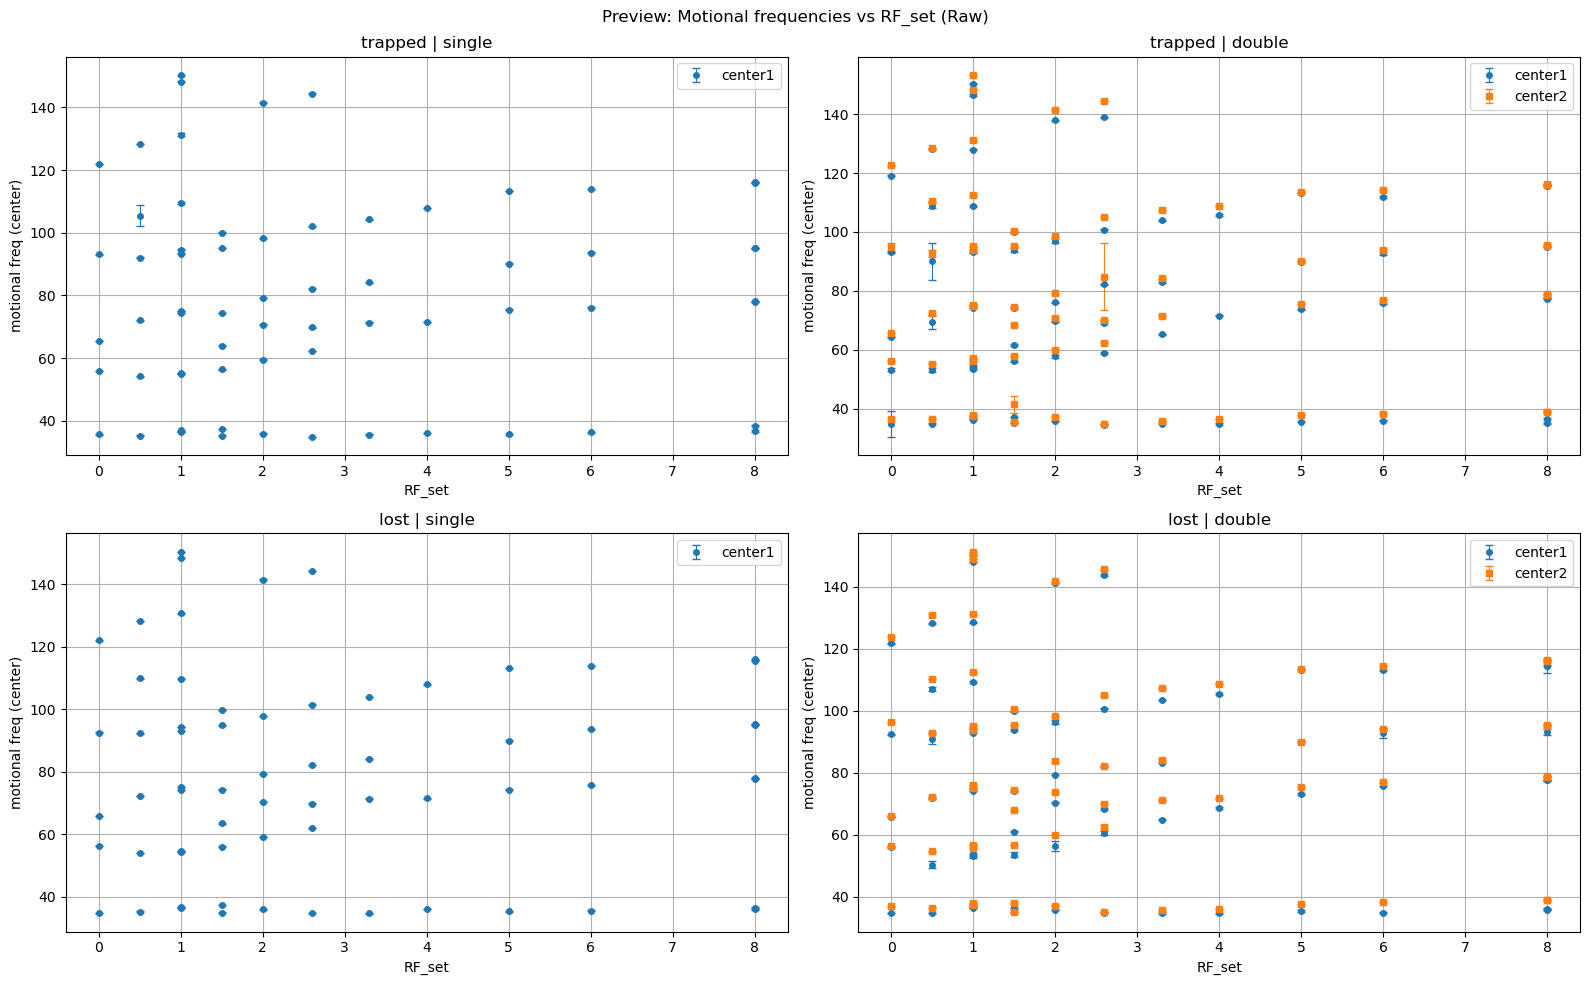

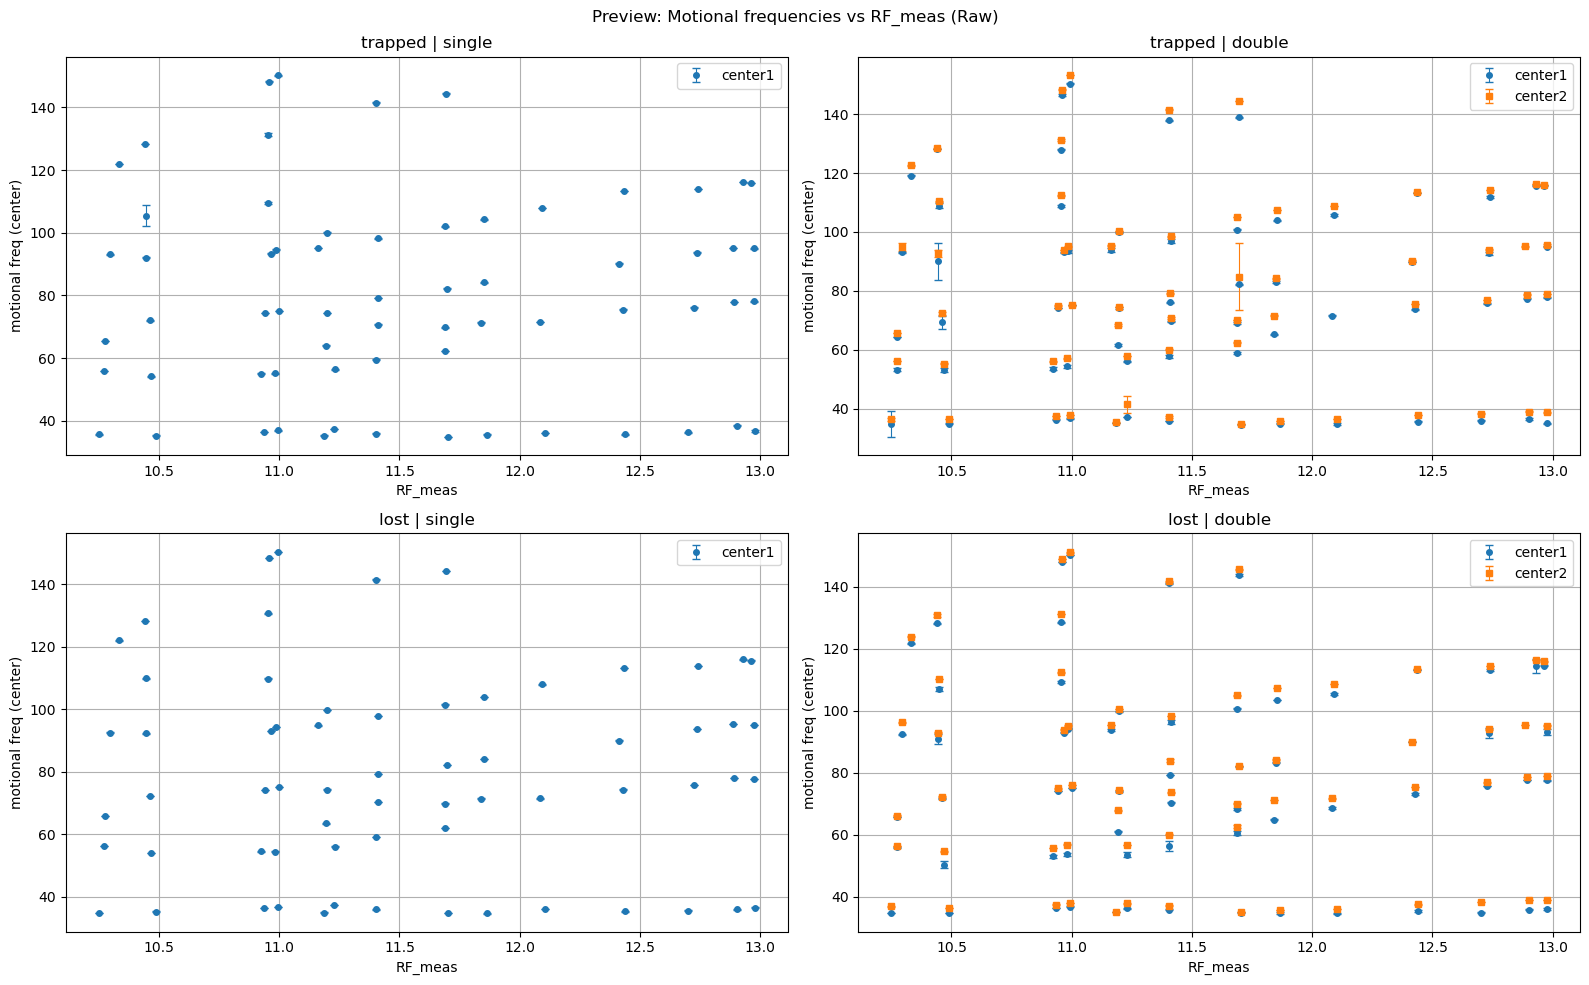

In [6]:
mistake_ts = {

    # RF=0.0 (Unstable RF Generator)
    "20251209_170328",
    "20251209_171547",
    "20251209_172238",
    "20251209_174008",
    "20251209_180316",

    # RF-0.5 (Too far away from other points)
    "20251210_132650",
    "20251210_134258",
    "20251210_135743",
    "20251210_141831",
    "20251210_142612",
    "20251210_143519",

    # RF=1.0 (Mistake)
    "20251211_135746",
    "20251211_140326",
    "20251211_141307",
    "20251211_141920",
    "20251211_142521",
    "20251211_143512",
    "20251211_144252",

    # RF=1.5 (Mistake)
    "20251211_162353",
    "20251211_163055",
    "20251211_164146",
    "20251211_164610",

    # RF=8.0 (Mistake) from your MATLAB snippet
    "20251216_151946",
    "20251216_152803",
    "20251216_154005",
    "20251216_154620",

}

# 确保 keep 是 bool
if "keep" not in df.columns:
    df["keep"] = True
df["keep"] = df["keep"].astype(bool)

# 标记 mistake
df.loc[df["timestamp"].isin(mistake_ts), "keep"] = False

print("Removed mistake rows:", df["timestamp"].isin(mistake_ts).sum())

fig1 = plot_groups(df, "RF_set",  "Preview: Motional frequencies vs RF_set (Raw)",
                   savepath=outdir/"preview_motional_vs_RF_set.png")

fig2 = plot_groups(df, "RF_meas", "Preview: Motional frequencies vs RF_meas (Raw)",
                   savepath=outdir/"preview_motional_vs_RF_meas.png")

plt.show()

# Filter Out Low Quality Fittings

In [8]:
QC = {
    "min_r2_single": 0.80,
    "min_r2_double": 0.80,
    "max_center_sigma": 1.0,      # 你也可以设一个上限，比如 2.0（取决于单位）
    "min_sigma_param": 0.02,         # 这是拟合 sigma 的下限，不是 center 的不确定度
    "require_status_ok": True,
}

In [9]:
def qc_filter(d: pd.DataFrame) -> pd.DataFrame:
    m = np.ones(len(d), dtype=bool)

    if QC["require_status_ok"] and "status" in d.columns:
        m &= (d["status"].astype(str).str.lower() == "ok")

    # R2 阈值（按 single/double 不同阈值）
    r2 = d.get("score_R2", pd.Series(np.nan, index=d.index)).astype(float)
    kind = d["fit_kind"].astype(str)

    m &= np.where(kind.eq("single"), r2 >= QC["min_r2_single"], True)
    m &= np.where(kind.eq("double"), r2 >= QC["min_r2_double"], True)

    # center1 必须存在
    m &= np.isfinite(d.get("center1_Value", np.nan).astype(float))
    m &= np.isfinite(d.get("center1_Sigma1", np.nan).astype(float))
    m &= (d.get("center1_Sigma1", np.inf).astype(float) > 0)
    m &= (d.get("center1_Sigma1", np.inf).astype(float) <= QC["max_center_sigma"])

    return d[m].copy()


In [10]:
def plot_groups_filtered(df_in: pd.DataFrame, xcol: str, title: str, savepath: Path | None = None):
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    axes = axes.ravel()

    groups = [
        ("trapped", "single"),
        ("trapped", "double"),
        ("lost",    "single"),
        ("lost",    "double"),
    ]

    for ax, (dt, fk) in zip(axes, groups):
        d = df_in[(df_in["data_type"] == dt) & (df_in["fit_kind"] == fk)].copy()

        d = d[np.isfinite(d[xcol].astype(float))]

        ax.set_title(f"{dt} | {fk}")
        ax.set_xlabel(xcol)
        ax.set_ylabel("motional freq (center)")

        if len(d) == 0:
            ax.text(0.05, 0.9, "No data", transform=ax.transAxes)
            ax.grid(True)
            continue

        x = d[xcol].astype(float).to_numpy()

        # ---- NEW: selection masks (default True if columns absent) ----
        use1 = np.ones(len(d), dtype=bool)
        use2 = np.ones(len(d), dtype=bool)
        if "use_center1" in d.columns:
            use1 = d["use_center1"].astype(bool).to_numpy()
        if "use_center2" in d.columns:
            use2 = d["use_center2"].astype(bool).to_numpy()

        # center1
        y1 = d["center1_Value"].astype(float).to_numpy()
        e1 = d["center1_Sigma1"].astype(float).to_numpy()
        m1 = np.isfinite(x) & np.isfinite(y1) & np.isfinite(e1) & (e1 > 0)

        # only filter by use_center* for double (optional but makes intention clear)
        if fk == "double":
            m1 &= use1

        ax.errorbar(
            x[m1], y1[m1], yerr=e1[m1],
            fmt='o', ms=4, lw=0.8, capsize=3, linestyle='none', label='center1'
        )

        # center2 (double)
        if fk == "double" and "center2_Value" in d.columns and "center2_Sigma1" in d.columns:
            y2 = d["center2_Value"].astype(float).to_numpy()
            e2 = d["center2_Sigma1"].astype(float).to_numpy()
            m2 = np.isfinite(x) & np.isfinite(y2) & np.isfinite(e2) & (e2 > 0)
            m2 &= use2

            ax.errorbar(
                x[m2], y2[m2], yerr=e2[m2],
                fmt='s', ms=4, lw=0.8, capsize=3, linestyle='none', label='center2'
            )

        ax.grid(True)
        ax.legend(loc="best")

    fig.suptitle(title)
    fig.tight_layout()
    if savepath is not None:
        fig.savefig(savepath, dpi=200)
    return fig


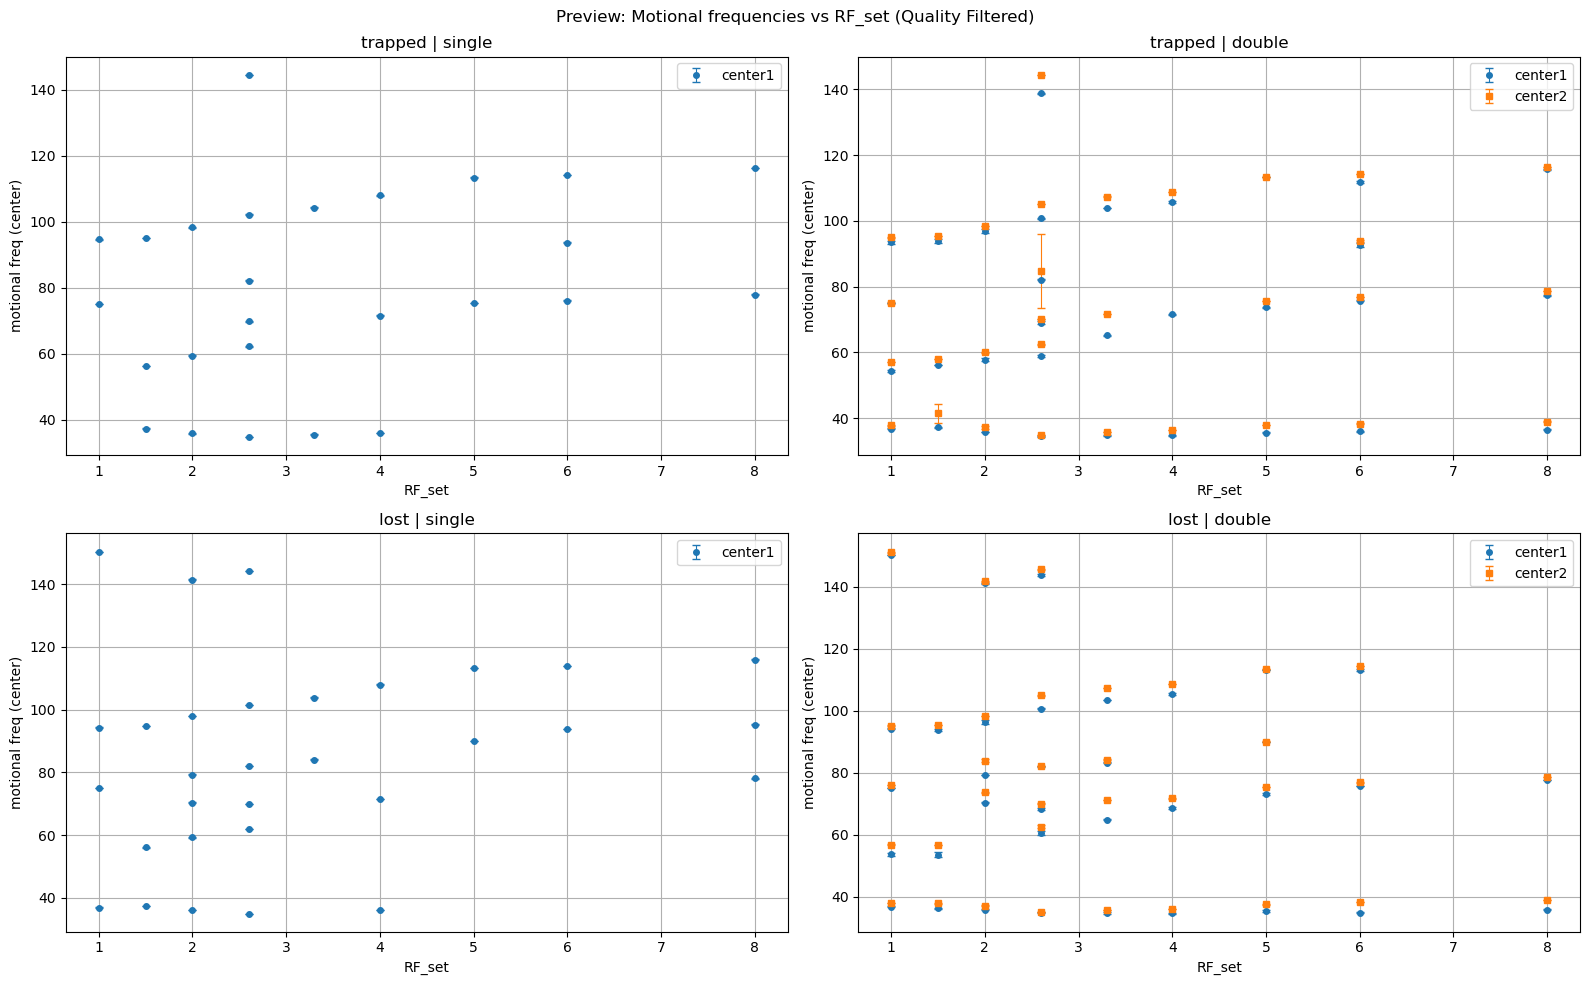

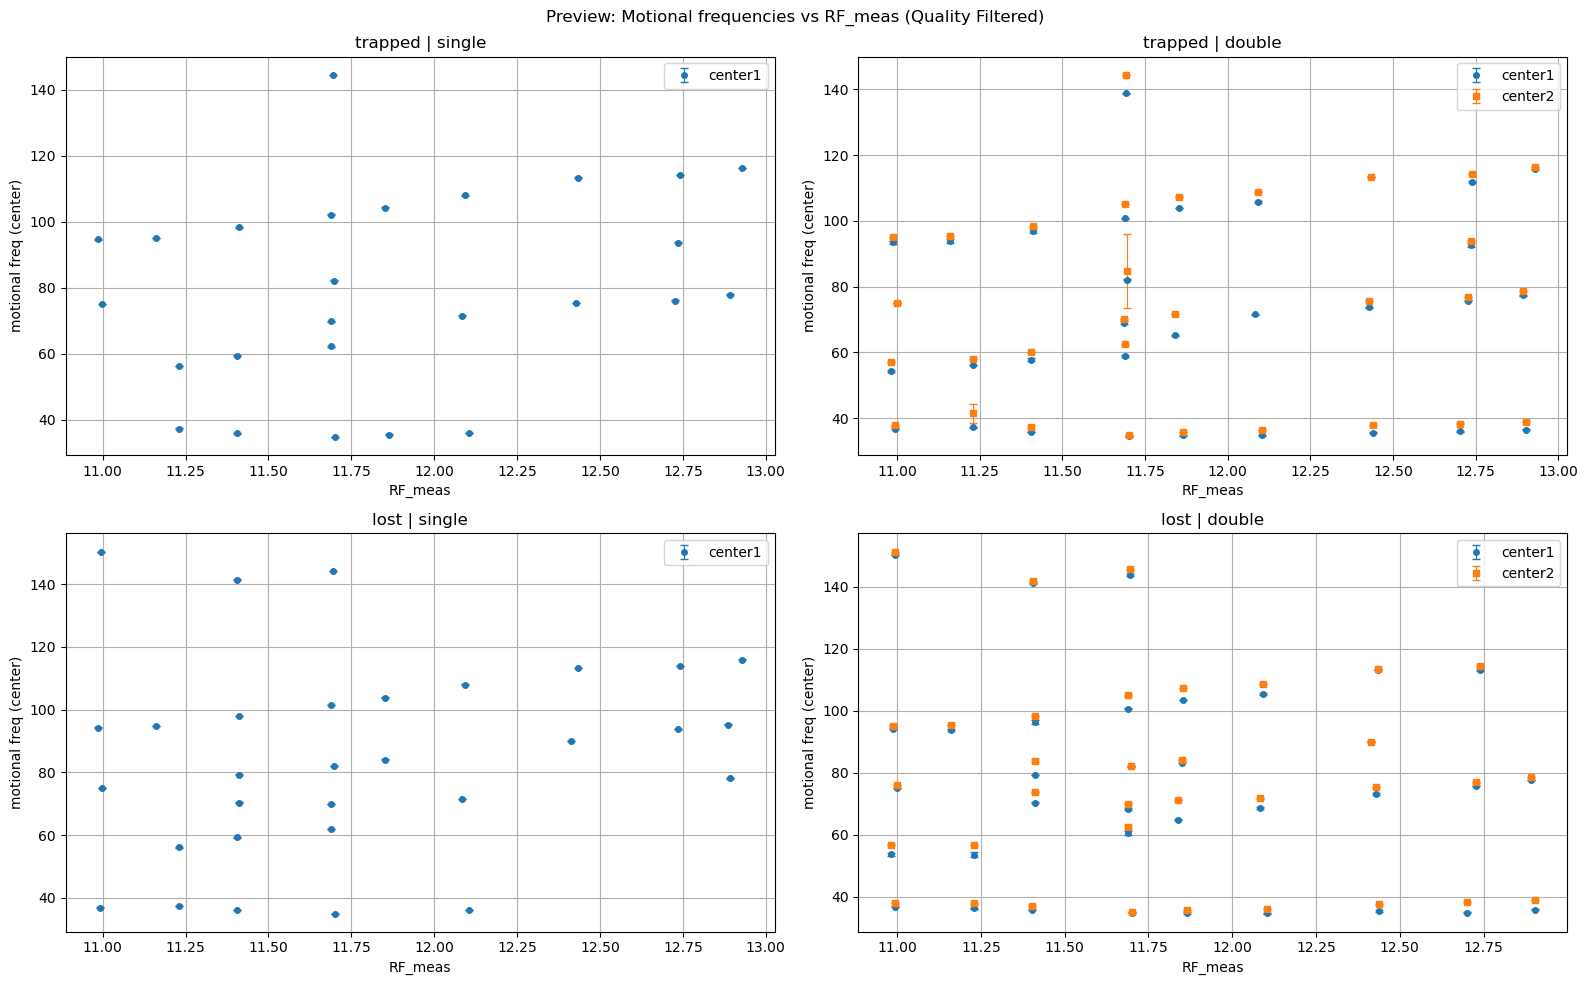

In [11]:
# Main Logic
df_qc = qc_filter(df[df["keep"] == True])

fig1 = plot_groups(df_qc, "RF_set",  "Preview: Motional frequencies vs RF_set (Quality Filtered)",
                   savepath=outdir/"preview_motional_vs_RF_set.png")

fig2 = plot_groups(df_qc, "RF_meas", "Preview: Motional frequencies vs RF_meas (Quality Filtered)",
                   savepath=outdir/"preview_motional_vs_RF_meas.png")

plt.show()

# Select Main Peak from Double Gaussian Fittings

In [13]:
def classify_double_peaks_simple(
    df: pd.DataFrame,
    *,
    enforce_center_order: bool = True,
    weak_ratio_min: float = 0.15,   # 次峰/主峰 < 0.15 标记为 weak（但不影响主峰选择）
    inplace: bool = False,
) -> pd.DataFrame:
    """
    只做一件事：对 double 模型，选“复合强度 p_eff 最大”的那个峰作为主峰。
    产出列：
      - p1_effheight, p2_effheight, peak_ratio
      - primary_component
      - use_center1/use_center2（double 只保留一个）
      - double_class = "double_primary"（single 就 "single"）
      - weak_rejected / weak_component（用于debug）
    """
    if not inplace:
        df = df.copy()

    # normalize fit_kind
    if "fit_kind" not in df.columns:
        if "model" in df.columns:
            m = df["model"].astype(str).str.lower()
            df["fit_kind"] = np.where(m.str.contains("double"), "double",
                               np.where(m.str.contains("single"), "single", m))
        else:
            df["fit_kind"] = "unknown"
    df["fit_kind"] = df["fit_kind"].astype(str).str.lower()

    is_double = df["fit_kind"].eq("double")
    is_single = df["fit_kind"].eq("single")

    # safe numeric cols
    def fcol(name: str) -> pd.Series:
        if name in df.columns:
            return pd.to_numeric(df[name], errors="coerce")
        return pd.Series(np.nan, index=df.index, dtype=float)

    c1 = fcol("center1_Value")
    c2 = fcol("center2_Value")
    s1 = fcol("sigma1_Value")
    s2 = fcol("sigma2_Value")
    a1 = fcol("amp1_Value")
    a2 = fcol("amp2_Value")

    # optional: enforce center1 < center2 by swapping common pairs
    if enforce_center_order and bool(is_double.any()):
        need_swap = is_double & np.isfinite(c1) & np.isfinite(c2) & (c1 > c2)
        if bool(need_swap.any()):
            swap_pairs = [
                ("center1_Value", "center2_Value"),
                ("amp1_Value", "amp2_Value"),
                ("sigma1_Value", "sigma2_Value"),
                ("center1_Sigma1", "center2_Sigma1"),
                ("amp1_Sigma1", "amp2_Sigma1"),
                ("sigma1_Sigma1", "sigma2_Sigma1"),
                ("center1_CI95_low", "center2_CI95_low"),
                ("center1_CI95_high", "center2_CI95_high"),
                ("amp1_CI95_low", "amp2_CI95_low"),
                ("amp1_CI95_high", "amp2_CI95_high"),
                ("sigma1_CI95_low", "sigma2_CI95_low"),
                ("sigma1_CI95_high", "sigma2_CI95_high"),
                ("center1_CI95_width", "center2_CI95_width"),
                ("amp1_CI95_width", "amp2_CI95_width"),
                ("sigma1_CI95_width", "sigma2_CI95_width"),
            ]
            for A, B in swap_pairs:
                if A in df.columns and B in df.columns:
                    tmp = df.loc[need_swap, A].copy()
                    df.loc[need_swap, A] = df.loc[need_swap, B].values
                    df.loc[need_swap, B] = tmp.values

            # reload after swap
            c1 = fcol("center1_Value")
            c2 = fcol("center2_Value")
            s1 = fcol("sigma1_Value")
            s2 = fcol("sigma2_Value")
            a1 = fcol("amp1_Value")
            a2 = fcol("amp2_Value")

    # compute effective heights (MATLAB form exp(-(dx^2)/(sigma^2)))
    dsep = np.abs(c1 - c2)
    amp_ok = np.isfinite(a1) & np.isfinite(a2)
    sig_ok = np.isfinite(s1) & np.isfinite(s2) & (s1 > 0) & (s2 > 0)
    ok = is_double & amp_ok & sig_ok & np.isfinite(dsep)

    e21 = np.exp(-(dsep**2) / (s2**2))
    e12 = np.exp(-(dsep**2) / (s1**2))
    p1 = np.abs(a1) + np.abs(a2) * e21
    p2 = np.abs(a2) + np.abs(a1) * e12

    pmin = np.minimum(p1, p2)
    pmax = np.maximum(p1, p2)
    peak_ratio = pmin / pmax

    df["p1_effheight"] = np.where(ok, p1, np.nan)
    df["p2_effheight"] = np.where(ok, p2, np.nan)
    df["peak_ratio"]   = np.where(ok, peak_ratio, np.nan)

    # primary component = argmax(p1,p2); fallback: center1
    choose1 = pd.Series(True, index=df.index)
    both_ok = ok & np.isfinite(p1) & np.isfinite(p2)
    choose1[both_ok] = p1[both_ok] >= p2[both_ok]

    df["primary_component"] = np.where(is_double, np.where(choose1, 1.0, 2.0), 1.0)

    # use_center flags: double only keep primary
    df["use_center1"] = True
    df["use_center2"] = False
    df.loc[is_double, "use_center1"] = (df.loc[is_double, "primary_component"] == 1.0)
    df.loc[is_double, "use_center2"] = (df.loc[is_double, "primary_component"] == 2.0)

    # simple class labels for debug
    df["double_class"] = "single"
    df.loc[is_double, "double_class"] = "double_primary"

    # weak peak tagging (optional)
    df["weak_rejected"] = False
    df["weak_component"] = np.nan
    weak = ok & np.isfinite(peak_ratio) & (peak_ratio < weak_ratio_min)
    df.loc[weak, "weak_rejected"] = True
    # weak component = the smaller p
    weak_comp = np.where(p1 <= p2, 1.0, 2.0)
    df.loc[weak, "weak_component"] = weak_comp[weak]

    # optional note
    df["decision_note"] = ""
    df.loc[is_double, "decision_note"] = "primary_by_effective_height"
    df.loc[weak, "decision_note"] = df.loc[weak, "decision_note"] + f" | weak_ratio<{weak_ratio_min}"

    return df

In [14]:
def classify_double_peaks(
    df: pd.DataFrame,
    *,
    # ---- pedestal (底座+真峰) ----
    w_ped: float = 5.0,
    s_ped: float = 1.0,
    ped_peak_ratio_min: float = 1.00,

    # ---- true double ----
    s_true: float = 1.0,

    # ---- shoulder-friendly true double (bimodality test) ----
    r_min: float = 0.25,
    v_min: float = 0.15,
    k_sep: float = 1.0,
    w_true_max: float = 5.0,

    # ---- sanity / bounds ----
    sigma_min_bound: float | None = 0.02,
    sigma_bound_tol: float = 0.05,
    sigma_real_max: float | None = None,
    enforce_center_order: bool = True,

    # ---- ambiguous ----
    ambiguous_policy: str = "best_one",
    ambiguous_pick: str = "dominant",

    # ---- weak peak reject gate ----
    weak_ratio_min: float = 0.15,
    weak_apply_to: str = "true_double",
    weak_policy: str = "reject_component",

    inplace: bool = False,
) -> pd.DataFrame:
    """
    Classify / select peaks for *double-gaussian fits* and set use_center1/use_center2.

    The function assumes each row corresponds to one fit result (single or double) for a given:
        (timestamp, data_type)  where data_type ∈ {"lost", "trapped"}.

    It computes several geometry/intensity metrics from the fitted parameters and assigns:
        double_class ∈ {"pedestal_plus_peak", "true_double", "ambiguous", "invalid_double", "single"}

    Then it sets:
        use_center1, use_center2  (which peaks are considered "selected" downstream)
        primary_component         (1 or 2; for single it's 1)

    ----------------------------------------------------------------------
    Required columns (for full behavior)
    ----------------------------------------------------------------------
    For double rows you need:
        center1_Value, center2_Value
        sigma1_Value,  sigma2_Value
        amp1_Value,    amp2_Value
        (optional but useful) center1_Sigma1, center2_Sigma1
    For both single/double you may have:
        fit_kind ("single"/"double") or model ("single_gaussian"/"double_gaussian")

    ----------------------------------------------------------------------
    Key computed metrics (read these first)
    ----------------------------------------------------------------------
    Let:
        d = |center1 - center2|
        W = max(sigma1, sigma2) / min(sigma1, sigma2)                (width ratio)
        S = d / sqrt(sigma1^2 + sigma2^2)                            (normalized separation)
        sep_over_min_sigma = d / min(sigma1, sigma2)                 (separation in units of narrow sigma)

    Effective peak heights at each center (robust vs overlap):
        p1 = |amp1| + |amp2| * exp(-(d^2)/(sigma2^2))    # height above baseline at center1 from BOTH components
        p2 = |amp2| + |amp1| * exp(-(d^2)/(sigma1^2))    # height above baseline at center2 from BOTH components

    Intensity ratio:
        peak_ratio = min(p1, p2) / max(p1, p2)           # 0..1 ; smaller means second peak is weak

    Saddle/valley depth at midpoint m=(c1+c2)/2:
        v = |amp1|*exp(-((d/2)^2)/(sigma1^2)) + |amp2|*exp(-((d/2)^2)/(sigma2^2))
        valley_ratio = (min(p1,p2) - v) / min(p1,p2)     # 0..1 ; larger means clearer "two-hump" shape
        If valley_ratio ~ 0 => looks like one broad peak + shoulder, not clearly bimodal.

    ----------------------------------------------------------------------
    Parameter meanings and how to tune them
    ----------------------------------------------------------------------

    [Pedestal / background model control]
    w_ped:
        "How unequal do the widths need to be before we even consider 'pedestal + peak'?"
        - Larger w_ped => harder to call pedestal_plus_peak (fewer pedestal classifications)
        - Smaller w_ped => more pedestal classifications (risk misclassifying main+shoulder)

    s_ped:
        "How close do the centers need to be (relative to widths) to call pedestal?"
        Uses S = d / sqrt(s1^2+s2^2).
        - Smaller s_ped => requires centers to be very close to call pedestal (more conservative)
        - Larger s_ped => pedestal triggers even when centers are moderately separated

    ped_peak_ratio_min:
        "In a pedestal_candidate (W>=w_ped & S<=s_ped), require the narrow peak to be not weaker than wide peak."
        Uses p_narrow >= ped_peak_ratio_min * p_wide.
        Interpretation:
        - If ped_peak_ratio_min is high (e.g. 1.0), you ONLY call pedestal if narrow >= wide.
          That effectively treats many cases as main+shoulder instead of pedestal.
        - If ped_peak_ratio_min is low (e.g. 0.3), pedestal triggers even when narrow is weaker.

        **Rule of thumb**
        - If you often see 'wide hump is main peak' and narrow is a shoulder: increase ped_peak_ratio_min
        - If you truly see broad baseline + sharp real resonance sitting on it: decrease ped_peak_ratio_min

    [True double control]
    s_true:
        "Strong evidence threshold: if S >= s_true, treat as true_double (subject to other gates)."
        - Larger s_true => requires peaks to be more separated to auto-call true_double
        - Smaller s_true => easier to call true_double (more doubles)

        IMPORTANT INTERACTION with w_true_max:
        In your current code you also require (W <= w_true_max), which can block true_double
        for wide+sharp genuine cases. If you want 'S alone decides true_double', remove that W gate.

    [Bimodality (two-hump) test thresholds]
    r_min:
        "Minimum relative strength of the smaller peak (peak_ratio >= r_min) to accept true_double via bimodality test."
        - Larger r_min => rejects weak shoulders / tiny bumps (more likely to keep only main peak)
        - Smaller r_min => keeps weaker second peaks

    v_min:
        "Minimum valley depth between peaks (valley_ratio >= v_min) to accept true_double via bimodality test."
        - Larger v_min => only accept very clear two-hump shapes
        - Smaller v_min => accept shoulder-like doubles more readily

    k_sep:
        "Minimum separation in units of the *narrower* sigma: sep_over_min_sigma >= k_sep."
        - Larger k_sep => requires clearer separation relative to linewidth (stricter)
        - Smaller k_sep => allows close/overlapping peaks to count as bimodal

    w_true_max:
        "Upper bound on width ratio W for calling true_double."
        - Smaller w_true_max => blocks wide+sharp cases from being true_double (can be too harsh)
        - Larger w_true_max => allows wide+sharp true_double

        WARNING:
        If w_true_max < w_ped, you create a 'no-man zone' where:
            W not large enough for pedestal, but too large for true_double -> becomes ambiguous.
        If you keep this parameter, make sure w_true_max >= w_ped (or remove the gate).

    [Sanity / bounds]
    sigma_min_bound:
        The lower bound used in your fitting (or hard reject threshold).
        Here used to flag cases where sigma is stuck at the bound (unreliable).
        - Set to None to disable this check.

    sigma_bound_tol:
        How close to sigma_min_bound counts as "stuck at bound".
        Example: tol=0.05 means sigma <= 1.05*sigma_min_bound is treated as bound-stuck.

    sigma_real_max:
        Optional global upper bound for sigma to be considered "reasonable".
        Set None to disable.

    enforce_center_order:
        If True, ensures center1 < center2 by swapping (center/amp/sigma and their uncertainty columns).
        This prevents component identity from flipping across runs.

    [Ambiguous handling]
    ambiguous_policy:
        - "best_one": choose exactly ONE peak for downstream (use_center1/use_center2 only one True)
        - "both": keep both peaks even if ambiguous

    ambiguous_pick:
        Only used if ambiguous_policy == "best_one".
        - "dominant": choose the peak with larger effective height (p1 vs p2) => tends to pick main peak.
        - "sharp": choose the peak with larger |amp|/sigma => tends to pick narrow shoulders.

        For your workflow (extracting main resonance), "dominant" is usually correct.

    [Weak peak reject gate]
    weak_ratio_min:
        If peak_ratio < weak_ratio_min, we mark one component as "weak".
        Used to automatically reject extremely weak secondary peaks even if true_double.

    weak_apply_to:
        - "true_double": apply weak-peak rejection only when row is already true_double.
        - "any_double": apply to any valid double (stronger filtering)

    weak_policy:
        - "reject_component": keep row's class, but only select the strong peak (use_center only one True).
        - "downgrade_to_ambiguous": change class to ambiguous, then select strong peak via ambiguous logic.

    ----------------------------------------------------------------------
    Practical tuning recipe (fast)
    ----------------------------------------------------------------------
    1) If too many ambiguous that look like true double (like your W=4.91 S=1.12 case):
       - Either increase w_true_max (>= w_ped), or REMOVE the W<=w_true_max gate for true_double.
       - Or decrease s_true.

    2) If you keep selecting tiny bumps as second peak:
       - Increase weak_ratio_min (e.g. 0.2)
       - Increase r_min and/or v_min

    3) If pedestal_plus_peak mislabels main hump as pedestal:
       - Increase ped_peak_ratio_min (more likely treat as main+shoulder)
       - Or increase w_ped / decrease s_ped (harder to call pedestal)

    Returns
    -------
    DataFrame
        Same rows as input plus classification columns:
            double_class, use_center1, use_center2, primary_component, etc.
    """


    if not inplace:
        df = df.copy()

    def fcol(name: str) -> pd.Series:
        if name in df.columns:
            return pd.to_numeric(df[name], errors="coerce")
        return pd.Series(np.nan, index=df.index, dtype=float)

    # ---- normalize fit_kind ----
    if "fit_kind" not in df.columns:
        if "model" in df.columns:
            m = df["model"].astype(str).str.lower()
            df["fit_kind"] = np.where(m.str.contains("double"), "double",
                               np.where(m.str.contains("single"), "single", m))
        else:
            df["fit_kind"] = "unknown"
    df["fit_kind"] = df["fit_kind"].astype(str).str.lower()

    is_double = df["fit_kind"].eq("double")
    is_single = df["fit_kind"].eq("single")

    # ---- parameters ----
    c1 = fcol("center1_Value")
    c2 = fcol("center2_Value")
    s1 = fcol("sigma1_Value")
    s2 = fcol("sigma2_Value")
    a1 = fcol("amp1_Value")
    a2 = fcol("amp2_Value")
    ce1 = fcol("center1_Sigma1")
    ce2 = fcol("center2_Sigma1")

    # ---- enforce center1 < center2 by swapping common pairs ----
    if enforce_center_order and bool(is_double.any()):
        need_swap = is_double & np.isfinite(c1) & np.isfinite(c2) & (c1 > c2)
        if bool(need_swap.any()):
            swap_pairs = [
                ("center1_Value", "center2_Value"),
                ("amp1_Value", "amp2_Value"),
                ("sigma1_Value", "sigma2_Value"),
                ("center1_Sigma1", "center2_Sigma1"),
                ("amp1_Sigma1", "amp2_Sigma1"),
                ("sigma1_Sigma1", "sigma2_Sigma1"),
                ("center1_CI95_low", "center2_CI95_low"),
                ("center1_CI95_high", "center2_CI95_high"),
                ("amp1_CI95_low", "amp2_CI95_low"),
                ("amp1_CI95_high", "amp2_CI95_high"),
                ("sigma1_CI95_low", "sigma2_CI95_low"),
                ("sigma1_CI95_high", "sigma2_CI95_high"),
                ("center1_CI95_width", "center2_CI95_width"),
                ("amp1_CI95_width", "amp2_CI95_width"),
                ("sigma1_CI95_width", "sigma2_CI95_width"),
            ]
            for A, B in swap_pairs:
                if A in df.columns and B in df.columns:
                    tmp = df.loc[need_swap, A].copy()
                    df.loc[need_swap, A] = df.loc[need_swap, B].values
                    df.loc[need_swap, B] = tmp.values

            # reload after swap
            c1 = fcol("center1_Value")
            c2 = fcol("center2_Value")
            s1 = fcol("sigma1_Value")
            s2 = fcol("sigma2_Value")
            a1 = fcol("amp1_Value")
            a2 = fcol("amp2_Value")
            ce1 = fcol("center1_Sigma1")
            ce2 = fcol("center2_Sigma1")

    # ---- bounds / validity ----
    bound_bad = pd.Series(False, index=df.index)
    if sigma_min_bound is not None:
        thr = sigma_min_bound * (1.0 + sigma_bound_tol)
        bound_bad = bound_bad | (s1 <= thr) | (s2 <= thr)

    valid = (
        np.isfinite(c1) & np.isfinite(c2) &
        np.isfinite(s1) & np.isfinite(s2) &
        (s1 > 0) & (s2 > 0) &
        (~bound_bad)
    )
    if sigma_real_max is not None:
        valid = valid & (s1 <= sigma_real_max) & (s2 <= sigma_real_max)

    # ---- W, S ----
    smin = np.minimum(s1, s2)
    smax = np.maximum(s1, s2)
    W = smax / smin

    dsep = np.abs(c1 - c2)
    denom = np.sqrt(s1**2 + s2**2)
    S = dsep / denom
    sep_over_min_sigma = dsep / smin

    # ---- effective heights & bimodality metrics ----
    amp_ok = np.isfinite(a1) & np.isfinite(a2)

    # MATLAB-style gaussian: exp(-(dx^2)/(sigma^2))
    e21 = np.exp(-(dsep**2) / (s2**2))
    e12 = np.exp(-(dsep**2) / (s1**2))

    p1 = np.abs(a1) + np.abs(a2) * e21
    p2 = np.abs(a2) + np.abs(a1) * e12

    mexp1 = np.exp(-((dsep / 2.0) ** 2) / (s1**2))
    mexp2 = np.exp(-((dsep / 2.0) ** 2) / (s2**2))
    vmid = np.abs(a1) * mexp1 + np.abs(a2) * mexp2

    pmin = np.minimum(p1, p2)
    pmax = np.maximum(p1, p2)

    peak_ratio = pmin / pmax
    valley_ratio = (pmin - vmid) / pmin
    valley_ratio = np.where(np.isfinite(valley_ratio), valley_ratio, np.nan)
    valley_ratio = np.clip(valley_ratio, 0.0, 1.0)

    # ---- diagnostics ----
    df["W_sigma_ratio"] = np.where(is_double, W, np.nan)
    df["S_separation"] = np.where(is_double, S, np.nan)
    df["sep_over_min_sigma"] = np.where(is_double, sep_over_min_sigma, np.nan)
    df["peak_ratio"] = np.where(is_double & amp_ok, peak_ratio, np.nan)
    df["valley_ratio"] = np.where(is_double & amp_ok, valley_ratio, np.nan)
    df["p1_effheight"] = np.where(is_double & amp_ok, p1, np.nan)
    df["p2_effheight"] = np.where(is_double & amp_ok, p2, np.nan)

    # ============================================================
    # pedestal candidate + NEW gating against "main+shoulder"
    # ============================================================
    wide_is_1 = s1 > s2  # True: component1 is wider

    pedestal_candidate = is_double & valid & (W >= w_ped) & (S <= s_ped)

    # If amp exists, compute p_narrow / p_wide to decide if it is really pedestal+peak
    p_wide = np.where(wide_is_1, p1, p2)
    p_narrow = np.where(wide_is_1, p2, p1)

    # default: if no amp, fall back to old pedestal_candidate
    ped_mask = pedestal_candidate.copy()

    if bool((amp_ok & pedestal_candidate).any()):
        ped_mask = pedestal_candidate & (~amp_ok)  # amp missing: keep pedestal
        ped_mask = ped_mask | (pedestal_candidate & amp_ok & (p_narrow >= ped_peak_ratio_min * p_wide))

    # shoulder-like: would have been pedestal by (W,S) but narrow is too weak -> treat as ambiguous
    shoulder_like = pedestal_candidate & amp_ok & (p_narrow < ped_peak_ratio_min * p_wide)

    # ============================================================
    # true double
    # ============================================================
    true_strong = (
        is_double & valid & (~ped_mask) & amp_ok &
        (S >= s_true) &
        (valley_ratio >= v_min) &     # Must have a saddle between two peaks
        (peak_ratio >= r_min)         # Secondary peak must not be too weak
        # (W <= w_true_max)
    )

    true_bimodal = (
        is_double & valid & (~ped_mask) & amp_ok &
        (W <= w_true_max) &
        (sep_over_min_sigma >= k_sep) &
        (peak_ratio >= r_min) &
        (valley_ratio >= v_min)
    )

    true_mask = true_strong | true_bimodal
    amb_mask = is_double & valid & (~ped_mask) & (~true_mask)
    invalid_double = is_double & (~valid)

    # ---- init outputs ----
    df["double_class"] = "single"
    df.loc[is_double, "double_class"] = "ambiguous"
    df.loc[ped_mask, "double_class"] = "pedestal_plus_peak"
    df.loc[true_mask, "double_class"] = "true_double"
    df.loc[invalid_double, "double_class"] = "invalid_double"

    # Shoulder-like override: force ambiguous
    df.loc[shoulder_like, "double_class"] = "ambiguous"

    df["use_center1"] = True
    df["use_center2"] = False
    df.loc[is_double, "use_center2"] = True  # will override below

    df["primary_component"] = np.where(is_double, np.nan, 1.0)
    df["pedestal_component"] = np.nan
    df["weak_component"] = np.nan
    df["weak_rejected"] = False

    df["decision_note"] = ""
    df.loc[ped_mask, "decision_note"] = f"pedestal(W>={w_ped},S<={s_ped},narrow>= {ped_peak_ratio_min}*wide)"
    df.loc[ped_mask & (~amp_ok) & pedestal_candidate, "decision_note"] = f"pedestal_no_amp(W>={w_ped},S<={s_ped})"
    df.loc[shoulder_like, "decision_note"] = f"not_pedestal(narrow<{ped_peak_ratio_min}*wide) -> ambiguous"
    df.loc[true_strong, "decision_note"] = f"true_strong(S>={s_true})"
    df.loc[true_bimodal & (~true_strong), "decision_note"] = f"true_bimodal(r>={r_min},v>={v_min},sep>={k_sep})"
    df.loc[amb_mask, "decision_note"] = "ambiguous"
    df.loc[invalid_double, "decision_note"] = "invalid_double"

    # ---- pedestal_plus_peak: keep narrow only ----
    # pedestal = wider component; peak = narrower component
    ped_comp = np.where(wide_is_1, 1.0, 2.0)
    peak_comp = np.where(wide_is_1, 2.0, 1.0)

    df.loc[ped_mask, "pedestal_component"] = ped_comp[ped_mask]
    df.loc[ped_mask, "primary_component"] = peak_comp[ped_mask]
    df.loc[ped_mask, "use_center1"] = (df.loc[ped_mask, "primary_component"] == 1)
    df.loc[ped_mask, "use_center2"] = (df.loc[ped_mask, "primary_component"] == 2)

    # ---- true_double: keep both (for now; weak gate later may reject one) ----
    td = df["double_class"].eq("true_double")
    df.loc[td, "use_center1"] = True
    df.loc[td, "use_center2"] = True
    df.loc[td, "primary_component"] = np.nan
    df.loc[td, "pedestal_component"] = np.nan

    # ---- ambiguous handling ----
    if ambiguous_policy not in ("best_one", "both"):
        raise ValueError("ambiguous_policy must be 'best_one' or 'both'")
    if ambiguous_policy == "both":
        amb = df["double_class"].eq("ambiguous") & is_double & valid
        df.loc[amb, "use_center1"] = True
        df.loc[amb, "use_center2"] = True
        df.loc[amb, "primary_component"] = np.nan
    else:
        if ambiguous_pick not in ("dominant", "sharp"):
            raise ValueError("ambiguous_pick must be 'dominant' or 'sharp'")

        amb = df["double_class"].eq("ambiguous") & is_double & valid

        choose1 = pd.Series(False, index=df.index)

        if ambiguous_pick == "dominant":
            both_p_ok = amp_ok & np.isfinite(p1) & np.isfinite(p2)
            choose1[both_p_ok] = p1[both_p_ok] >= p2[both_p_ok]

            need_fb = ~both_p_ok
            both_ce_ok = np.isfinite(ce1) & np.isfinite(ce2)
            choose1[need_fb & both_ce_ok] = ce1[need_fb & both_ce_ok] <= ce2[need_fb & both_ce_ok]
            rest = need_fb & ~both_ce_ok
            choose1[rest] = s1[rest] <= s2[rest]

            df.loc[amb, "decision_note"] = df.loc[amb, "decision_note"] + " | best_one=dominant"
        else:
            prom1 = np.abs(a1) / s1
            prom2 = np.abs(a2) / s2
            both_ok = amp_ok & np.isfinite(prom1) & np.isfinite(prom2)
            choose1[both_ok] = prom1[both_ok] >= prom2[both_ok]

            need_fb = ~both_ok
            both_ce_ok = np.isfinite(ce1) & np.isfinite(ce2)
            choose1[need_fb & both_ce_ok] = ce1[need_fb & both_ce_ok] <= ce2[need_fb & both_ce_ok]
            rest = need_fb & ~both_ce_ok
            choose1[rest] = s1[rest] <= s2[rest]

            df.loc[amb, "decision_note"] = df.loc[amb, "decision_note"] + " | best_one=sharp"

        primary = np.where(choose1, 1.0, 2.0)
        df.loc[amb, "primary_component"] = primary[amb]
        df.loc[amb, "use_center1"] = (df.loc[amb, "primary_component"] == 1)
        df.loc[amb, "use_center2"] = (df.loc[amb, "primary_component"] == 2)

    # ---- invalid_double: select none ----
    inv = df["double_class"].eq("invalid_double")
    df.loc[inv, "use_center1"] = False
    df.loc[inv, "use_center2"] = False
    df.loc[inv, "primary_component"] = np.nan
    df.loc[inv, "pedestal_component"] = np.nan

    # ============================================================
    # weak peak reject gate
    # ============================================================
    if weak_policy not in ("reject_component", "downgrade_to_ambiguous"):
        raise ValueError("weak_policy must be 'reject_component' or 'downgrade_to_ambiguous'")
    if weak_apply_to not in ("true_double", "any_double"):
        raise ValueError("weak_apply_to must be 'true_double' or 'any_double'")

    if weak_apply_to == "true_double":
        gate_base = df["double_class"].eq("true_double")
    else:
        gate_base = is_double & valid & (~ped_mask)

    weak_gate = gate_base & amp_ok & np.isfinite(peak_ratio) & (peak_ratio < weak_ratio_min)

    weak_comp = np.where(p1 <= p2, 1.0, 2.0)
    df.loc[weak_gate, "weak_component"] = weak_comp[weak_gate]
    df.loc[weak_gate, "weak_rejected"] = True
    df.loc[weak_gate, "decision_note"] = df.loc[weak_gate, "decision_note"] + f" | weak_reject(r<{weak_ratio_min})"

    if weak_policy == "downgrade_to_ambiguous":
        df.loc[weak_gate, "double_class"] = "ambiguous"
        strong_comp = np.where(weak_comp == 1.0, 2.0, 1.0)
        df.loc[weak_gate, "primary_component"] = strong_comp[weak_gate]
        df.loc[weak_gate, "use_center1"] = (df.loc[weak_gate, "primary_component"] == 1)
        df.loc[weak_gate, "use_center2"] = (df.loc[weak_gate, "primary_component"] == 2)
    else:
        strong_comp = np.where(weak_comp == 1.0, 2.0, 1.0)
        df.loc[weak_gate, "primary_component"] = strong_comp[weak_gate]
        df.loc[weak_gate, "use_center1"] = (df.loc[weak_gate, "primary_component"] == 1)
        df.loc[weak_gate, "use_center2"] = (df.loc[weak_gate, "primary_component"] == 2)

    return df

In [15]:
df_classified = classify_double_peaks(df_qc)
#df_classified = classify_double_peaks_simple(df_qc)

df_classified

C:\Users\lluoz\AppData\Local\Temp\ipykernel_8936\4226158350.py:441: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[False False False False True True False False True True True False True
 True False False False False True False False False False False False
 False False False False False True True True True False False False False
 False False True True False False False True False False False False
 False False True False False False False False False False False False
 False False False False False]' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  choose1[both_p_ok] = p1[both_p_ok] >= p2[both_p_ok]


,key,timestamp,date,time,data_type,fit_kind,model,sign_mode,status,fail_reason,...,p1_effheight,p2_effheight,double_class,use_center1,use_center2,primary_component,pedestal_component,weak_component,weak_rejected,decision_note
44,20251210_182135_lost_double,20251210_182135,20251210,182135,lost,double,double_gaussian,peak,ok,NaN,...,0.032308,0.048072,ambiguous,False,True,2.0,NaN,NaN,False,ambiguous | best_one=dominant
45,20251210_182135_lost_single,20251210_182135,20251210,182135,lost,single,single_gaussian,peak,ok,NaN,...,NaN,NaN,single,True,False,1.0,NaN,NaN,False,
46,20251210_182135_trapped_double,20251210_182135,20251210,182135,trapped,double,double_gaussian,dip,ok,NaN,...,0.034238,0.050154,ambiguous,False,True,2.0,NaN,NaN,False,ambiguous | best_one=dominant
48,20251210_182826_lost_double,20251210_182826,20251210,182826,lost,double,double_gaussian,peak,ok,NaN,...,0.024736,0.055544,ambiguous,False,True,2.0,NaN,NaN,False,ambiguous | best_one=dominant
50,20251210_182826_trapped_double,20251210_182826,20251210,182826,trapped,double,double_gaussian,dip,ok,NaN,...,0.026671,0.062402,ambiguous,False,True,2.0,NaN,NaN,False,ambiguous | best_one=dominant
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
235,20251216_141520_trapped_single,20251216_141520,20251216,141520,trapped,single,single_gaussian,dip,ok,NaN,...,NaN,NaN,single,True,False,1.0,NaN,NaN,False,
237,20251216_142522_lost_single,20251216_142522,20251216,142522,lost,single,single_gaussian,peak,ok,NaN,...,NaN,NaN,single,True,False,1.0,NaN,NaN,False,
241,20251216_143214_lost_single,20251216_143214,20251216,143214,lost,single,single_gaussian,peak,ok,NaN,...,NaN,NaN,single,True,False,1.0,NaN,NaN,False,
242,20251216_143214_trapped_double,20251216_143214,20251216,143214,trapped,double,double_gaussian,dip,ok,NaN,...,0.037131,0.046688,ambiguous,False,True,2.0,NaN,NaN,False,ambiguous | best_one=dominant


In [16]:
# 1) IO helpers (MATLAB-style)
# =========================
def trimmed_mean(x, trimpct=0.10):
    x = np.asarray(x, dtype=float).ravel()
    x = x[np.isfinite(x)]
    if x.size == 0:
        return np.nan
    x = np.sort(x)
    n = x.size
    k = int(np.floor(n * trimpct))
    k = min(k, (n - 1) // 2)
    return float(np.mean(x[k:n-k]))


def _resolve_file(path_no_ext: Path) -> Path:
    """Try to find file with no extension or common extensions."""
    candidates = [
        path_no_ext,
        Path(str(path_no_ext) + ".csv"),
        Path(str(path_no_ext) + ".txt"),
        Path(str(path_no_ext) + ".dat"),
        Path(str(path_no_ext) + ".npy"),
    ]
    for p in candidates:
        if p.exists():
            return p
    raise FileNotFoundError(f"Cannot find file for: {path_no_ext} (tried no-ext/.csv/.txt/.dat/.npy)")


def _load_vector_file(path_no_ext: Path) -> np.ndarray:
    p = _resolve_file(path_no_ext)
    if p.suffix.lower() == ".npy":
        arr = np.load(p)
        return np.asarray(arr, dtype=float).ravel()

    # Try numpy loadtxt (fast)
    try:
        arr = np.loadtxt(p, dtype=float)
        return np.asarray(arr, dtype=float).ravel()
    except Exception:
        pass

    # Try genfromtxt (robust)
    try:
        arr = np.genfromtxt(p, dtype=float)
        return np.asarray(arr, dtype=float).ravel()
    except Exception:
        pass

    # Try pandas sniff
    arr = pd.read_csv(p, header=None, sep=None, engine="python").values.squeeze()
    return np.asarray(arr, dtype=float).ravel()


def read_run_data(timestamp: str, base_data_dir: Path) -> dict:
    """
    Mimic your MATLAB readData(ts):
      x = ts_arr_of_setpoints
      trapped = ts_ratio_signal
      lost = ts_ratio_lost
      act_rf = trimmedmean(ts_act_RF_amplitude)
    Directory: base_data_dir / YYYYMMDD / {ts}_{entry}[.ext]
    """
    date = timestamp.split("_")[0]
    ddir = Path(base_data_dir) / date

    x = _load_vector_file(ddir / f"{timestamp}_arr_of_setpoints")
    trapped = _load_vector_file(ddir / f"{timestamp}_ratio_signal")
    lost = _load_vector_file(ddir / f"{timestamp}_ratio_lost")
    act_rfs = _load_vector_file(ddir / f"{timestamp}_act_RF_amplitude")

    act_rf = trimmed_mean(act_rfs, 0.10)

    # Sort by x and clean
    x = np.asarray(x, float).ravel()
    trapped = np.asarray(trapped, float).ravel()
    lost = np.asarray(lost, float).ravel()

    idx = np.argsort(x)
    x, trapped, lost = x[idx], trapped[idx], lost[idx]

    good = np.isfinite(x) & np.isfinite(trapped) & np.isfinite(lost)
    x, trapped, lost = x[good], trapped[good], lost[good]

    return {"timestamp": timestamp, "RF_meas": act_rf, "x": x, "trapped": trapped, "lost": lost}


# =========================
# 2) Rebuild fit curve from summary row
# =========================
def gaussian_model(x, base, sign_mode, amp1, c1, s1, amp2=None, c2=None, s2=None):
    """
    Matches your MATLAB: exp(-((x-center)^2)/(sigma^2))  (no factor 2)
    """
    x = np.asarray(x, dtype=float)
    y = np.full_like(x, float(base))

    def g(amp, c, s):
        return float(amp) * np.exp(-((x - float(c)) ** 2) / (float(s) ** 2))

    if str(sign_mode).lower() == "dip":
        y = y - g(amp1, c1, s1)
        if amp2 is not None and c2 is not None and s2 is not None:
            y = y - g(amp2, c2, s2)
    else:
        y = y + g(amp1, c1, s1)
        if amp2 is not None and c2 is not None and s2 is not None:
            y = y + g(amp2, c2, s2)
    return y


def build_fit_curve_from_row(row: pd.Series, x_dense: np.ndarray):
    def getf(key):
        return pd.to_numeric(pd.Series([row.get(key, np.nan)]), errors="coerce").iloc[0]

    base = getf("base_Value")
    sign = row.get("sign_mode", "peak")

    amp1 = getf("amp1_Value")
    c1 = getf("center1_Value")
    s1 = getf("sigma1_Value")
    if not np.all(np.isfinite([base, amp1, c1, s1])) or s1 <= 0:
        return None

    fk = str(row.get("fit_kind", row.get("model", ""))).lower()
    if "double" in fk:
        amp2 = getf("amp2_Value")
        c2 = getf("center2_Value")
        s2 = getf("sigma2_Value")
        if np.all(np.isfinite([amp2, c2, s2])) and s2 > 0:
            return gaussian_model(x_dense, base, sign, amp1, c1, s1, amp2, c2, s2)

    return gaussian_model(x_dense, base, sign, amp1, c1, s1)


# =========================
# 3) Strict debug plotter (requires classification columns)
# =========================
def plot_debug_selection_strict(
    df_cls: pd.DataFrame,
    base_data_dir: Path,
    save_dir: Path,
    *,
    show_fit_curve: bool = True,
    prefer_curve_fit_kind: str = "double",
    max_plots: int | None = None,
):
    required = {"timestamp", "data_type", "fit_kind", "double_class", "use_center1", "use_center2",
                "center1_Value", "sign_mode", "base_Value", "amp1_Value", "sigma1_Value"}
    missing = [c for c in required if c not in df_cls.columns]
    if missing:
        raise ValueError(
            f"df_cls 缺少列 {missing}。\n"
            f"你必须先跑 classify_double_peaks(df_qc, ...) 生成 double_class/use_center1/use_center2。"
        )

    save_dir = Path(save_dir)
    save_dir.mkdir(parents=True, exist_ok=True)

    d = df_cls.copy()
    d["data_type"] = d["data_type"].astype(str).str.lower()
    d["fit_kind"] = d["fit_kind"].astype(str).str.lower()

    n_done = 0
    for (ts, dt), g in d.groupby(["timestamp", "data_type"], sort=False):
        if max_plots is not None and n_done >= max_plots:
            break

        ts = str(ts)
        dt = str(dt).lower()

        run = read_run_data(ts, Path(base_data_dir))
        x = run["x"]
        y = run[dt]

        fig, ax = plt.subplots(1, 1, figsize=(10, 6))
        ax.plot(x, y, ".", ms=3, label="data")

        # pick curve row
        if show_fit_curve:
            if (g["fit_kind"] == prefer_curve_fit_kind).any():
                rc = g[g["fit_kind"] == prefer_curve_fit_kind].iloc[0]
            else:
                rc = g.iloc[0]
            x_dense = np.linspace(np.min(x), np.max(x), max(2000, 20 * len(x)))
            yfit = build_fit_curve_from_row(rc, x_dense)
            if yfit is not None:
                ax.plot(x_dense, yfit, "-", lw=1.2, label=f"fit ({rc['fit_kind']})")

        # decision row: prefer double (where classification matters)
        if (g["fit_kind"] == "double").any():
            r = g[g["fit_kind"] == "double"].iloc[0]
        else:
            r = g.iloc[0]

        cls = str(r["double_class"])
        use1 = bool(r["use_center1"])
        use2 = bool(r["use_center2"])

        c1 = float(pd.to_numeric(pd.Series([r.get("center1_Value", np.nan)]), errors="coerce").iloc[0])
        c2 = float(pd.to_numeric(pd.Series([r.get("center2_Value", np.nan)]), errors="coerce").iloc[0])

        # selected / rejected markers
        if np.isfinite(c1):
            if use1:
                ax.axvline(c1, ls="--", lw=1.6, label=f"SELECT | {cls} | c1={c1:.6g}")
            else:
                ax.axvline(c1, ls=":", lw=1.2, alpha=0.45, label=f"REJECT | {cls} | c1={c1:.6g}")

        if np.isfinite(c2):
            if use2:
                ax.axvline(c2, ls="--", lw=1.6, label=f"SELECT | {cls} | c2={c2:.6g}")
            else:
                ax.axvline(c2, ls=":", lw=1.2, alpha=0.45, label=f"REJECT | {cls} | c2={c2:.6g}")

        # title
        rf_set = g["RF_set"].iloc[0] if "RF_set" in g.columns else np.nan
        rf_meas = g["RF_meas"].iloc[0] if "RF_meas" in g.columns else run.get("RF_meas", np.nan)

        W = r.get("W_sigma_ratio", np.nan)
        S = r.get("S_separation", np.nan)

        ax.set_title(f"{ts} | {dt} | class={cls} | W={W:.3g} | S={S:.3g} | RF_set={rf_set} | RF_meas={rf_meas:.6g}",
                     fontsize=11)
        ax.set_xlabel("Frequency")
        ax.set_ylabel(dt)
        ax.grid(True)

        # de-dup legend
        handles, labels = ax.get_legend_handles_labels()
        seen = set()
        H, L = [], []
        for h, lab in zip(handles, labels):
            if lab not in seen:
                seen.add(lab)
                H.append(h)
                L.append(lab)
        ax.legend(H, L, loc="best", fontsize=9)

        fig.tight_layout()
        out = save_dir / f"{ts}_{dt}_debug_{cls}.png"
        fig.savefig(out, dpi=200)
        plt.close(fig)

        n_done += 1

    print(f"Saved debug plots to: {save_dir}")


In [17]:
plot_debug_selection_strict(
    df_classified,
    base_data_dir=Path(r"C:\Users\lluoz\Documents\ZJLalala\Research\paper_writing\data_analysis\20251217\data"),
    save_dir=outdir / "debug_selection_plots_strict",
    show_fit_curve=True,
    prefer_curve_fit_kind="double",
)

Saved debug plots to: auto_fit_outputs\debug_selection_plots_strict


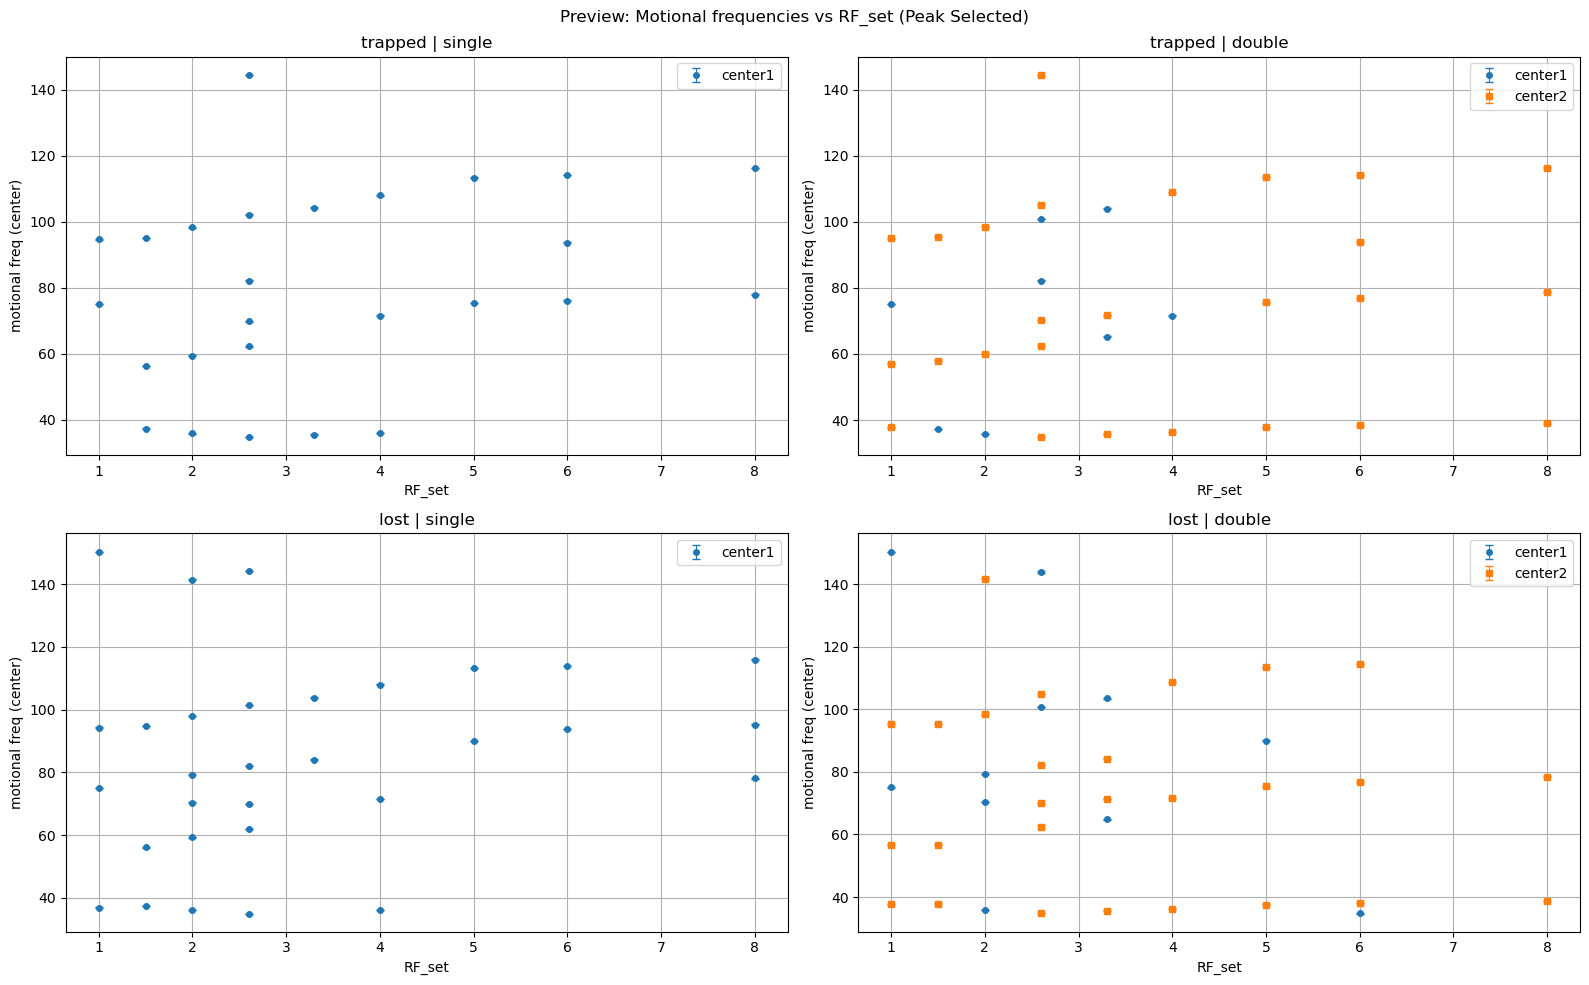

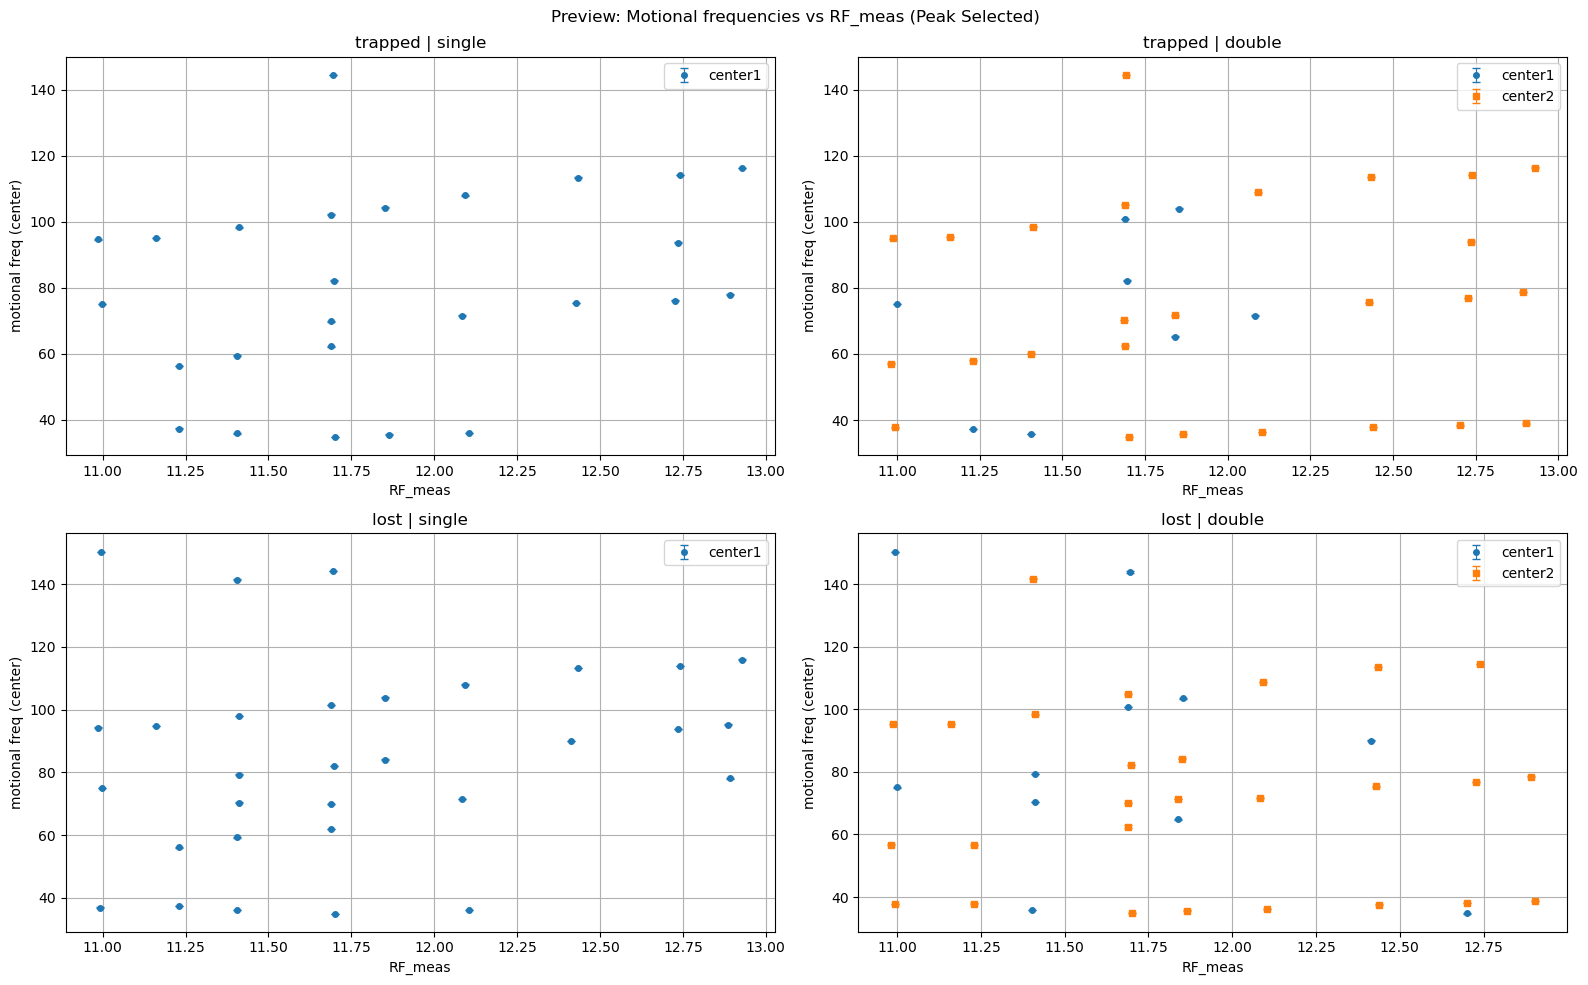

In [18]:
fig1 = plot_groups_filtered(df_classified, "RF_set",  "Preview: Motional frequencies vs RF_set (Peak Selected)",
                   savepath=outdir/"preview_motional_vs_RF_set.png")

fig2 = plot_groups_filtered(df_classified, "RF_meas", "Preview: Motional frequencies vs RF_meas (Peak Selected)",
                   savepath=outdir/"preview_motional_vs_RF_meas.png")

plt.show()

# Choose the Better Model Between Single and Double Gaussian Model

In [20]:
# 1) AICc-based model selection (single vs double)
# ============================================================
def choose_model_by_aicc(
    df_cls: pd.DataFrame,
    *,
    aicc_col: str = "score_AICc",
    key_cols=("timestamp", "data_type"),
    aicc_margin: float = 0.0,   # 0: strictly choose min AICc; 2/4/10 are common "evidence" thresholds
    require_double_valid: bool = True,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Returns:
      choice_table: one row per (timestamp, data_type), includes AICc_single/double, delta, chosen_fit_kind
      df_best: rows from df_cls corresponding to chosen model per group
    """
    d = df_cls.copy()
    d["fit_kind"] = d["fit_kind"].astype(str).str.lower()
    d["data_type"] = d["data_type"].astype(str).str.lower()
    d[aicc_col] = pd.to_numeric(d.get(aicc_col, np.nan), errors="coerce")

    # one row per candidate model within group
    # If there are duplicate single/double rows, keep the best (min AICc) of each kind
    agg = (
        d.groupby(list(key_cols) + ["fit_kind"], dropna=False)[aicc_col]
         .min()
         .unstack("fit_kind")
         .rename(columns={"single": "AICc_single", "double": "AICc_double"})
         .reset_index()
    )

    # delta > 0 => double better (lower AICc)
    agg["delta_AICc"] = agg["AICc_single"] - agg["AICc_double"]

    # default choice: whichever AICc is smaller, with optional margin
    # If AICc_double is smaller by >= margin => choose double else choose single
    chosen = []
    for _, r in agg.iterrows():
        a1 = r.get("AICc_single", np.nan)
        a2 = r.get("AICc_double", np.nan)

        if np.isfinite(a1) and np.isfinite(a2):
            if (a1 - a2) >= aicc_margin:
                chosen.append("double")
            else:
                chosen.append("single")
        elif np.isfinite(a2) and not np.isfinite(a1):
            chosen.append("double")
        elif np.isfinite(a1) and not np.isfinite(a2):
            chosen.append("single")
        else:
            chosen.append("none")

    agg["chosen_fit_kind_raw"] = chosen

    # Optional: if chosen is double but double row is invalid / selects no peaks, downgrade to single
    agg["chosen_fit_kind"] = agg["chosen_fit_kind_raw"]

    if require_double_valid:
        # build a quick lookup of whether each group's double row is usable
        # condition: exists a double row with status ok (if column exists) AND (use_center1 or use_center2) is True
        dd = d[d["fit_kind"].eq("double")].copy()

        # If columns missing, treat as not usable (you *should* have them after classify_double_peaks)
        if ("use_center1" in dd.columns) and ("use_center2" in dd.columns):
            use1 = dd["use_center1"].astype(bool)
            use2 = dd["use_center2"].astype(bool)
            dd["_double_usable"] = use1 | use2
        else:
            dd["_double_usable"] = False

        if "double_class" in dd.columns:
            dd["_double_usable"] &= ~dd["double_class"].astype(str).str.lower().eq("invalid_double")

        if "status" in dd.columns:
            dd["_double_usable"] &= dd["status"].astype(str).str.lower().eq("ok")

        double_ok = (
            dd.groupby(list(key_cols), dropna=False)["_double_usable"]
              .max()
              .reset_index()
              .rename(columns={"_double_usable": "double_usable"})
        )

        agg = agg.merge(double_ok, on=list(key_cols), how="left")
        agg["double_usable"] = agg["double_usable"].fillna(False)

        # downgrade rule
        downgrade = (agg["chosen_fit_kind"] == "double") & (~agg["double_usable"])
        agg.loc[downgrade, "chosen_fit_kind"] = "single"
        agg.loc[downgrade, "chosen_fit_kind_raw"] = agg.loc[downgrade, "chosen_fit_kind_raw"] + "->single(downgrade)"

    # Now pick df_best: for each group, take the row of chosen fit_kind with min AICc
    best_rows = []
    for _, r in agg.iterrows():
        if r["chosen_fit_kind"] == "none":
            continue
        mask = np.ones(len(d), dtype=bool)
        for kc in key_cols:
            mask &= (d[kc].astype(str) == str(r[kc]))
        mask &= d["fit_kind"].eq(r["chosen_fit_kind"])
        cand = d[mask].copy()
        if len(cand) == 0:
            continue
        # pick min AICc
        cand = cand.sort_values(aicc_col, ascending=True)
        best_rows.append(cand.iloc[0])

    df_best = pd.DataFrame(best_rows).reset_index(drop=True)

    # Attach chosen info back to df_best
    df_best = df_best.merge(
        agg[list(key_cols) + ["chosen_fit_kind", "chosen_fit_kind_raw", "AICc_single", "AICc_double", "delta_AICc"]],
        on=list(key_cols),
        how="left"
    )

    return agg, df_best


# ============================================================
# 2) Explode chosen rows into "final selected points"
#    (single -> one point; double -> points according to use_center1/use_center2)
# ============================================================
def build_selected_points(
    df_best: pd.DataFrame,
    *,
    key_cols=("timestamp", "data_type"),
) -> pd.DataFrame:
    rows = []

    for _, r in df_best.iterrows():
        fk = str(r.get("fit_kind", "")).lower()
        dt = str(r.get("data_type", "")).lower()

        base_common = {
            "timestamp": r.get("timestamp"),
            "date": r.get("date", None),
            "time": r.get("time", None),
            "data_type": dt,
            "RF_set": r.get("RF_set", np.nan),
            "RF_meas": r.get("RF_meas", np.nan),
            "model_chosen": fk,
            "chosen_fit_kind": r.get("chosen_fit_kind", fk),
            "AICc_single": r.get("AICc_single", np.nan),
            "AICc_double": r.get("AICc_double", np.nan),
            "delta_AICc": r.get("delta_AICc", np.nan),
            "score_R2": r.get("score_R2", np.nan),
            "score_SSE": r.get("score_SSE", np.nan),
            "score_RMSE": r.get("score_RMSE", np.nan),
            "sign_mode": r.get("sign_mode", None),
            "double_class": r.get("double_class", None),
            "decision_note": r.get("decision_note", None),
            "weak_rejected": r.get("weak_rejected", False),
            "weak_component": r.get("weak_component", np.nan),
        }

        def add_point(comp: int):
            c = r.get(f"center{comp}_Value", np.nan)
            ce = r.get(f"center{comp}_Sigma1", np.nan)
            s = r.get(f"sigma{comp}_Value", np.nan)
            a = r.get(f"amp{comp}_Value", np.nan)
            rows.append({
                **base_common,
                "component": comp,
                "center": c,
                "center_sigma": ce,
                "sigma": s,
                "amp": a,
            })

        if fk == "single":
            add_point(1)

        elif fk == "double":
            # require use_center flags; if missing, fallback to primary_component or both
            use1 = bool(r.get("use_center1", True))
            use2 = bool(r.get("use_center2", True))

            if use1:
                add_point(1)
            if use2:
                add_point(2)

        else:
            # unknown model: skip
            continue

    df_points = pd.DataFrame(rows)

    # numeric
    for col in ["RF_set", "RF_meas", "center", "center_sigma", "sigma", "amp", "AICc_single", "AICc_double", "delta_AICc"]:
        if col in df_points.columns:
            df_points[col] = pd.to_numeric(df_points[col], errors="coerce")

    return df_points


# ============================================================
# 3) Preview: plot selected points (lost/trapped separate)
# ============================================================
def preview_selected_points(
    df_points: pd.DataFrame,
    *,
    xcol: str = "RF_meas",     # or "RF_set"
    title_prefix: str = "Selected points",
    savepath: Path | None = None,
):
    fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=False)
    for ax, dt in zip(axes, ["trapped", "lost"]):
        d = df_points[df_points["data_type"] == dt].copy()
        d = d[np.isfinite(d[xcol].astype(float)) & np.isfinite(d["center"].astype(float))]

        ax.set_title(f"{dt}")
        ax.set_xlabel(xcol)
        ax.set_ylabel("center (freq)")
        ax.grid(True)

        if len(d) == 0:
            ax.text(0.05, 0.9, "No data", transform=ax.transAxes)
            continue

        x = d[xcol].astype(float).to_numpy()
        y = d["center"].astype(float).to_numpy()
        e = pd.to_numeric(d.get("center_sigma", np.nan), errors="coerce").to_numpy()

        # Use errorbar if sigma available, else scatter
        m = np.isfinite(e) & (e > 0)
        if m.any():
            ax.errorbar(x[m], y[m], yerr=e[m], fmt="o", ms=4, capsize=3, linestyle="none", label="with sigma")
        if (~m).any():
            ax.plot(x[~m], y[~m], "o", ms=4, label="no sigma")

        # optional: show which model chosen via marker edge (simple legend text instead of styling heavy)
        # (kept simple; you can split by model if you want)
        ax.legend(loc="best")

    fig.suptitle(f"{title_prefix} vs {xcol}")
    fig.tight_layout()

    if savepath is not None:
        savepath = Path(savepath)
        savepath.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(savepath, dpi=200)

    return fig


C:\Users\lluoz\AppData\Local\Temp\ipykernel_8936\2141119749.py:85: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  agg["double_usable"] = agg["double_usable"].fillna(False)


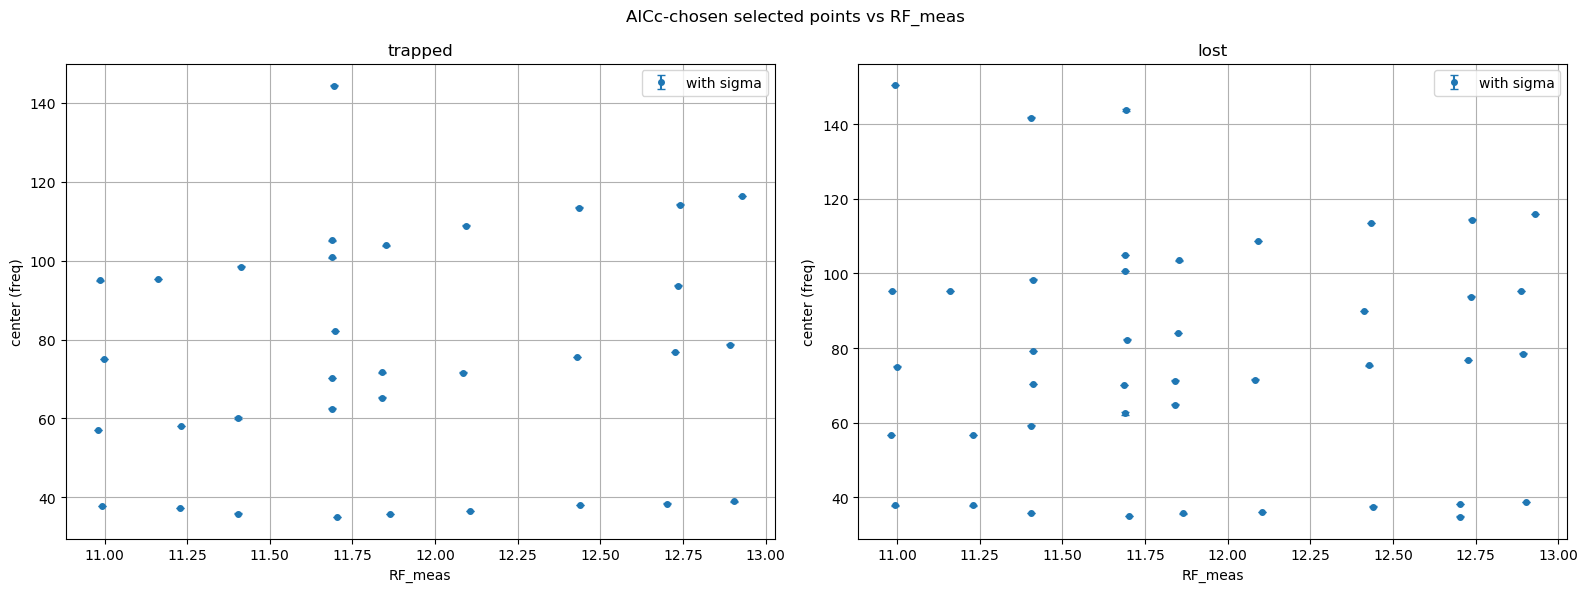

In [21]:
# df_qc = qc_filter(df[df["keep"]==True])
# df_cls = classify_double_peaks(df_qc, ...)  # 你已经做过

choice_table, df_best = choose_model_by_aicc(
    df_classified,
    aicc_margin=0.0,              # 先严格按 AICc 最小选；如果你想保守点改成 2 或 4
    require_double_valid=True
)

df_points = build_selected_points(df_best)

# 预览（trapped/lost 分开画）
outdir = Path("./auto_fit_outputs")
fig = preview_selected_points(
    df_points,
    xcol="RF_meas",
    title_prefix="AICc-chosen selected points",
    savepath=outdir / "preview_selected_points_vs_RF_meas.png"
)
plt.show()

# 保存最终点表（后面做 axial/radial 分类会用）
df_best.to_csv(outdir / "fit_selected_models.csv", index=False)
df_points.to_csv(outdir / "fit_selected_points_long.csv", index=False)

# Extract Final Result

In [23]:
def get_final_data_simple(df_best):

    columns_to_drop1 = ["key", "date", "time", "model", "sign_mode", "status", "fail_reason",
                        "keep", "note", "score_BIC", "score_SSE", "score_RMSE", 
                        "amp1_CI95_width", "amp1_CI95_low", "amp1_CI95_high",
                        "amp2_CI95_width", "amp2_CI95_low", "amp2_CI95_high",
                        "base_CI95_width", "base_CI95_low", "base_CI95_high",
                        "center1_CI95_width", "center1_CI95_low", "center1_CI95_high",
                        "center2_CI95_width", "center2_CI95_low", "center2_CI95_high",
                        "sigma1_CI95_width", "sigma1_CI95_low", "sigma1_CI95_high",
                        "sigma2_CI95_width", "sigma2_CI95_low", "sigma2_CI95_high",
                        "p1_effheight", "p2_effheight", "peak_ratio", "use_center1", "use_center2",
                        "weak_rejected", "weak_component", "decision_note",
                        "chosen_fit_kind", "chosen_fit_kind_raw", "double_class",
                        "soc", "AICc_single", "AICc_double",]

    # drop 时允许列不存在
    cols1 = [c for c in columns_to_drop1 if c in df_best.columns]

    df_trapped = df_best[df_best["data_type"] == "trapped"].drop(columns=cols1).copy()
    df_lost    = df_best[df_best["data_type"] == "lost"].drop(columns=cols1).copy()

    final_results = [df_trapped, df_lost]

    # ---- extract primary component to amp/center/sigma (vectorized) ----
    for df_result in final_results:
        # 统一 base 命名（只做一次）
        if "base_Value" in df_result.columns:
            df_result.rename(columns={"base_Value": "base_value"}, inplace=True)
        if "base_Sigma1" in df_result.columns:
            df_result.rename(columns={"base_Sigma1": "base_uncertainty"}, inplace=True)

        comp = pd.to_numeric(df_result["primary_component"], errors="coerce").fillna(1).astype(int)

        for key in ["amp", "center", "sigma"]:
            v1 = pd.to_numeric(df_result.get(f"{key}1_Value", np.nan), errors="coerce")
            v2 = pd.to_numeric(df_result.get(f"{key}2_Value", np.nan), errors="coerce")
            e1 = pd.to_numeric(df_result.get(f"{key}1_Sigma1", np.nan), errors="coerce")
            e2 = pd.to_numeric(df_result.get(f"{key}2_Sigma1", np.nan), errors="coerce")

            df_result[f"{key}_value"] = np.where(comp == 1, v1, v2)
            df_result[f"{key}_uncertainty"] = np.where(comp == 1, e1, e2)

    columns_to_drop2 = ["data_type",
                        "amp1_Value", "amp1_Sigma1", "amp2_Value", "amp2_Sigma1",
                        "center1_Value", "center1_Sigma1", "center2_Value", "center2_Sigma1",
                        "sigma1_Value", "sigma1_Sigma1", "sigma2_Value", "sigma2_Sigma1",
                        "primary_component"]

    cols2_trapped = [c for c in columns_to_drop2 if c in final_results[0].columns]
    cols2_lost    = [c for c in columns_to_drop2 if c in final_results[1].columns]

    return final_results[0].drop(columns=cols2_trapped), final_results[1].drop(columns=cols2_lost)


In [24]:
def get_final_data(df_best):
    columns_to_drop1 = [
        "key", "date", "time", "model", "sign_mode", "status", "fail_reason",
        "keep", "note", "score_BIC", "score_SSE", "score_RMSE",
        "amp1_CI95_width", "amp1_CI95_low", "amp1_CI95_high",
        "amp2_CI95_width", "amp2_CI95_low", "amp2_CI95_high",
        "base_CI95_width", "base_CI95_low", "base_CI95_high",
        "center1_CI95_width", "center1_CI95_low", "center1_CI95_high",
        "center2_CI95_width", "center2_CI95_low", "center2_CI95_high",
        "sigma1_CI95_width", "sigma1_CI95_low", "sigma1_CI95_high",
        "sigma2_CI95_width", "sigma2_CI95_low", "sigma2_CI95_high",
        "p1_effheight", "p2_effheight", "peak_ratio",
        "weak_rejected", "weak_component", "decision_note",
        "chosen_fit_kind", "chosen_fit_kind_raw", "double_class", "fit_extreme",
        "score_AICc", "score_R2",
        "AICc_single", "AICc_double", "delta_AICc", "delta_AICc", "W_sigma_ratio",
        "S_separation", "sep_over_min_sigma", "valley_ratio", "pedestal_component",
    ]

    def _process_one(df_in: pd.DataFrame) -> pd.DataFrame:
        df = df_in.copy()

        if "base_Value" in df.columns:
            df.rename(columns={"base_Value": "base_value"}, inplace=True)
        if "base_Sigma1" in df.columns:
            df.rename(columns={"base_Sigma1": "base_uncertainty"}, inplace=True)

        if "fit_kind" not in df.columns:
            if "model" in df.columns:
                m = df["model"].astype(str).str.lower()
                df["fit_kind"] = np.where(m.str.contains("double"), "double",
                                   np.where(m.str.contains("single"), "single", m))
            else:
                df["fit_kind"] = "unknown"
        df["fit_kind"] = df["fit_kind"].astype(str).str.lower()

        if "use_center1" not in df.columns:
            df["use_center1"] = True
        if "use_center2" not in df.columns:
            df["use_center2"] = df["fit_kind"].eq("double")

        use1 = df["use_center1"].astype(bool).to_numpy()
        use2 = df["use_center2"].astype(bool).to_numpy()
        fk = df["fit_kind"].to_numpy()

        comp_list = []
        for i in range(len(df)):
            if fk[i] == "single":
                comp_list.append([1])
            else:
                lst = []
                if use1[i]:
                    lst.append(1)
                if use2[i]:
                    lst.append(2)
                if not lst:
                    lst = [1]
                comp_list.append(lst)

        df["component"] = comp_list
        df = df.explode("component", ignore_index=True)
        df["component"] = pd.to_numeric(df["component"], errors="coerce").astype("Int64")

        comp = df["component"].fillna(1).astype(int)

        for key in ["amp", "center", "sigma"]:
            v1 = pd.to_numeric(df.get(f"{key}1_Value", np.nan), errors="coerce")
            v2 = pd.to_numeric(df.get(f"{key}2_Value", np.nan), errors="coerce")
            e1 = pd.to_numeric(df.get(f"{key}1_Sigma1", np.nan), errors="coerce")
            e2 = pd.to_numeric(df.get(f"{key}2_Sigma1", np.nan), errors="coerce")

            df[f"{key}_value"] = np.where(comp == 1, v1, v2)
            df[f"{key}_uncertainty"] = np.where(comp == 1, e1, e2)

        columns_to_drop2 = [
            "data_type",
            "amp1_Value", "amp1_Sigma1", "amp2_Value", "amp2_Sigma1",
            "center1_Value", "center1_Sigma1", "center2_Value", "center2_Sigma1",
            "sigma1_Value", "sigma1_Sigma1", "sigma2_Value", "sigma2_Sigma1",
            "primary_component",
            "use_center1", "use_center2",
        ]

        cols_drop = [c for c in (columns_to_drop1 + columns_to_drop2) if c in df.columns]
        df = df.drop(columns=cols_drop)

        preferred_order = [
            "timestamp", "RF_set", "RF_meas", "fit_kind", "component",
            "base_value", "base_uncertainty",
            "amp_value", "amp_uncertainty",
            "center_value", "center_uncertainty",
            "sigma_value", "sigma_uncertainty",
            "score_R2", "score_AICc"
        ]
        cols = [c for c in preferred_order if c in df.columns] + [c for c in df.columns if c not in preferred_order]
        df = df[cols]

        return df

    df_trapped_in = df_best[df_best["data_type"] == "trapped"]
    df_lost_in    = df_best[df_best["data_type"] == "lost"]

    df_trapped = _process_one(df_trapped_in)
    df_lost    = _process_one(df_lost_in)

    return df_trapped, df_lost


In [25]:
#df_trapped, df_lost = get_final_data_simple(df_best)
df_trapped, df_lost = get_final_data(df_best)

mask1 = (df_lost["RF_meas"] > 11.30) * (df_lost["RF_meas"] < 12.00)
mask2 = (df_lost["center_value"] > 50.0 ) * (df_lost["center_value"] < 90)
mask = mask1 * mask2
df_masked = df_lost[mask]

In [26]:
df_lost.columns

Index(['timestamp', 'RF_set', 'RF_meas', 'fit_kind', 'component', 'base_value',
       'base_uncertainty', 'amp_value', 'amp_uncertainty', 'center_value',
       'center_uncertainty', 'sigma_value', 'sigma_uncertainty',
       'RF_set_linear', 'RF_meas_uncertainty', 'RF_meas_linear',
       'RF_meas_uncertainty_linear'],
      dtype='object')

In [27]:
df_masked

,timestamp,RF_set,RF_meas,fit_kind,component,base_value,base_uncertainty,amp_value,amp_uncertainty,center_value,center_uncertainty,sigma_value,sigma_uncertainty,RF_set_linear,RF_meas_uncertainty,RF_meas_linear,RF_meas_uncertainty_linear
6,20251212_130740,2.0,11.403795,single,1,0.017832,0.000649,0.032255,0.001020,59.2126,0.082624,3.60180,0.154140,1.584893,0.000675,13.815916,0.002149
7,20251212_132040,2.0,11.412368,double,1,0.012783,0.000432,0.012312,0.000633,70.3515,0.063512,1.79330,0.120370,1.584893,0.001656,13.843235,0.005284
8,20251212_132653,2.0,11.410091,single,1,0.011851,0.000251,0.017534,0.000876,79.3049,0.024186,0.60578,0.036330,1.584893,0.001009,13.835960,0.003215
15,20251212_184222,2.6,11.689024,double,2,-0.026398,0.309890,0.023382,0.004570,62.5312,0.430700,2.74530,0.350660,1.819701,0.000964,14.753758,0.003276
16,20251212_184923,2.6,11.687633,double,2,0.013268,0.001840,0.033965,0.004163,70.0515,0.031576,0.73922,0.080031,1.819701,0.001285,14.749037,0.004367
17,20251212_185420,2.6,11.696636,double,2,0.009698,0.000621,0.011522,0.001572,82.2701,0.029293,0.40000,0.057761,1.819701,0.000758,14.779636,0.002580
22,20251215_121921,3.3,11.839510,double,1,0.019508,0.000540,0.037769,0.000694,64.8474,0.086367,5.64130,0.175610,2.137962,0.000814,15.273952,0.002862
23,20251215_121921,3.3,11.839510,double,2,0.019508,0.000540,0.037483,0.001372,71.2768,0.031592,1.14950,0.052398,2.137962,0.000814,15.273952,0.002862
24,20251215_123555,3.3,11.850500,single,1,0.014752,0.000368,0.014177,0.000738,84.0723,0.042703,1.07360,0.072084,2.137962,0.000582,15.312640,0.002050


# Identify Branches and Perform Fitting

In [101]:
# Identify Branches
def identify_and_plot(df_result, experiment_dict, mute_plot=False, average_yerr=False):

    mask = df_result.apply(
        lambda r: experiment_dict.get(r["timestamp"], None) == int(r["component"]),
        axis = 1
    )

    df_selected = df_result[mask].copy().sort_values(["RF_meas"])
    
    xs = df_selected["RF_meas_linear"]
    xerr = df_selected["RF_meas_uncertainty_linear"]
    ys = df_selected["center_value"]
    if average_yerr:
        yerr = [np.mean(df_selected["sigma_value"])] * len(df_selected["sigma_value"])
    else:
        yerr = df_selected["sigma_value"]

    if not mute_plot:
        plt.figure(figsize=(8, 6))
        plt.errorbar(xs, ys, xerr=xerr, yerr=yerr, 
                     fmt='o', markersize=5, capsize=3, 
                     ecolor='red', mfc='white', mec='blue',
                     label='Measured Data')
        
        plt.xlabel("Measured RF Amplitude on spectrum Analyzer (mW)")
        plt.ylabel("Resonance Frequency (MHz)")
        plt.title("Motional Frequency vs RF Amplitude")
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.legend()
        plt.show()

    return xs, ys, xerr, yerr, df_selected

In [30]:
# Fitting
def square_root1(x, a):
    return a * np.sqrt(x)

def square_root2(x, a, b):
    return a * np.sqrt(x - b)

def square_root3(x, a, c):
    return a * np.sqrt(x) + c

def square_root4(x, a, b, c):
    return a * np.sqrt(x - b) + c

def constant(x, c):
    return np.full_like(x, c, dtype=float)

def guess_square_root4_params(x, y, deltas=(0.5, 0.3, 1.0, 1.5, 2.0), b_upper=None, return_meta=False):
    """
    Initial guess for y = a * sqrt(x - b) + c

    Strategy:
      - Try b0 = min(x) - delta for several delta
      - With fixed b0, set u = sqrt(x - b0), then linear least squares: y ≈ a*u + c
      - Pick the (delta, b0) with smallest RSS

    Parameters
    ----------
    x, y : array-like or pandas Series
    deltas : iterable of float
        Candidate shifts for b0 = min(x) - delta.
    b_upper : float or None
        Optional constraint: require b0 <= b_upper (useful if your curve_fit bounds cap b).
    return_meta : bool
        If True, return (p0, meta_dict). Otherwise return p0 only.

    Returns
    -------
    p0 : list [a0, b0, c0]  (directly usable by scipy.optimize.curve_fit)
    meta (optional) : dict with delta and rss
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    if x.shape != y.shape:
        raise ValueError(f"x and y must have same shape, got {x.shape} vs {y.shape}")
    if x.size < 2:
        raise ValueError("Need at least 2 points to guess parameters.")

    xmin = float(np.min(x))
    best = None  # will store: (rss, a0, b0, c0, delta)

    for delta in deltas:
        delta = float(delta)
        b0 = xmin - delta

        if (b_upper is not None) and (b0 > float(b_upper)):
            continue

        dx = x - b0
        if np.any(dx <= 0):
            continue

        u = np.sqrt(dx)

        # Linear LS: y ≈ a*u + c
        A = np.column_stack([u, np.ones_like(u)])
        coef, *_ = np.linalg.lstsq(A, y, rcond=None)
        a0, c0 = coef[0], coef[1]

        yhat = a0 * u + c0
        rss = float(np.sum((y - yhat) ** 2))

        cand = (rss, float(a0), float(b0), float(c0), delta)
        if (best is None) or (cand[0] < best[0]):
            best = cand

    if best is None:
        raise RuntimeError("No valid initial guess found. Try different deltas (or relax b_upper).")

    rss, a0, b0, c0, delta = best
    p0 = [a0, b0, c0]

    if return_meta:
        return p0, {"delta": delta, "rss": rss}
    return p0

def fit_and_plot(xs, ys, xerr, yerr, func, p0=None, bounds=(-np.inf, np.inf)):

    # Perform Fitting
    popt, pcov = curve_fit(
        func, xs, ys,
        p0=p0, bounds=bounds,
        sigma=yerr, absolute_sigma=True,
    )

    # Fitted Curve
    xfit = np.linspace(np.min(xs), np.max(xs), 1000)
    yfit = func(xfit, *popt)

    # Plot Result
    plt.figure(figsize=(8, 6))
    plt.errorbar(xs, ys, xerr=xerr, yerr=yerr, 
                 fmt='o', markersize=5, capsize=3, 
                 ecolor='red', mfc='white', mec='blue',
                 label='Measured Data')
    plt.plot(xfit, yfit, label='fitted_data')
    plt.xlabel("Measured RF Amplitude on spectrum Analyzer (mW)")
    plt.ylabel("Resonance Frequency (MHz)")
    plt.title("Motional Frequency vs RF Amplitude")
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()
    plt.show()

    return popt, pcov

In [149]:
average_yerr=True

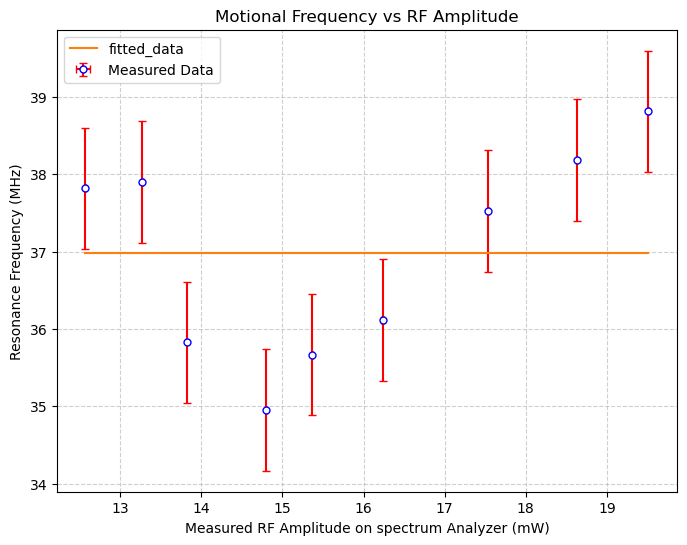

array([36.97658889])

In [151]:
# Just for recording, probably useful in the future, chose the relatively strong peak for each RF amplitude
data_axial = {
    #"20251209_170328": 2,
    #"20251210_132650": 1,
    #"20251210_132650": 2,
    "20251210_182135": 2,
    "20251212_130011": 1,
    "20251212_171614": 2,
    "20251212_183713": 2,
    "20251215_121232": 2,
    "20251215_140843": 2,
    "20251215_153823": 2,
    "20251215_173206": 1,
    "20251215_173206": 2,
    "20251216_140715": 2,
}

x_axial, y_axial, xerr_axial, yerr_axial, df_axial = identify_and_plot(df_lost, data_axial, mute_plot=True, average_yerr=average_yerr)
popt_axial, pcov_axial = fit_and_plot(x_axial, y_axial, xerr_axial, yerr_axial, constant)
popt_axial

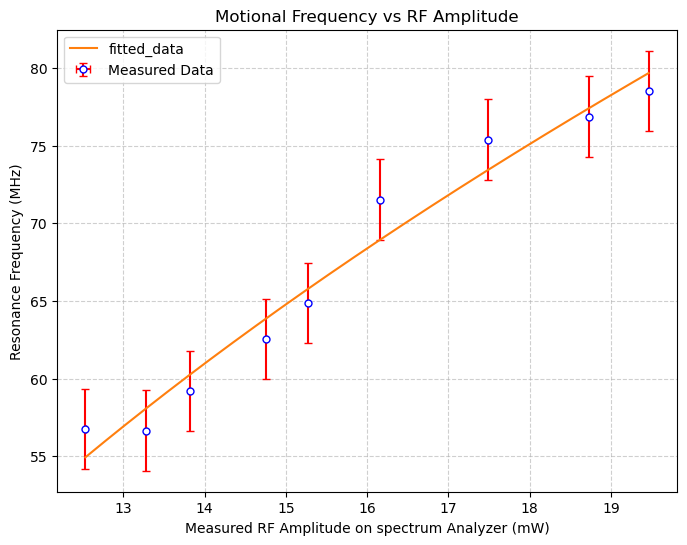

array([22.44689303,  5.80554259, -3.29580314])

In [152]:
# Suspected Radial Branch 1
data_branch1 = {
    #"20251209_171547": 1,  # RF_amplitude = 0.0, suspicious
    #"20251210_134258": 1,  # RF_amplitude = 0.5
    "20251210_182826": 2,  # RF_amplitude = 1.0
    "20251212_130740": 1,  # RF_amplitude = 2.0
    "20251212_172308": 2,  # RF_amplitude = 1.5
    "20251212_184222": 2,  # RF_amplitude = 2.6
    "20251215_121921": 1,  # RF_amplitude = 3.3
    "20251215_141616": 1,  # RF_amplitude = 4.0
    "20251215_154627": 2,  # RF_amplitude = 5.0
    "20251215_174013": 2,  # RF_amplitude = 6.0
    "20251216_141520": 2,  # RF_amplitude = 8.0
}

x_branch1, y_branch1, xerr_branch1, yerr_branch1, df_branch1 = identify_and_plot(df_lost, data_branch1, mute_plot=True, average_yerr=average_yerr)
p0_branch1 = guess_square_root4_params(x_branch1, y_branch1)
bounds_branch1 = ((0.0, -np.inf, -np.inf), (np.inf, 11.0, np.inf))
popt_branch1, pcov_branch1 = fit_and_plot(
    x_branch1, y_branch1, xerr_branch1, yerr_branch1,
    square_root4, p0=p0_branch1, bounds=bounds_branch1
)
popt_branch1

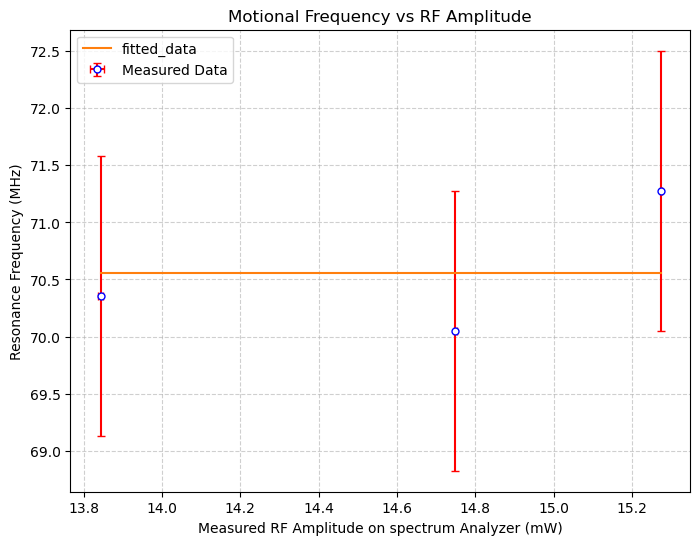

array([70.55993333])

In [154]:
data_axial2 = {
    "20251212_132040": 1,  # RF_amplitude = 2.0
    "20251212_184923": 2,  # RF_amplitude = 2.6
    "20251215_121921": 2,  # RF_amplitude = 3.3
}

x_axial2, y_axial2, xerr_axial2, yerr_axial2, df_axial2 = identify_and_plot(df_lost, data_axial2, mute_plot=True, average_yerr=average_yerr)
p0_axial2 = [29.0, 0.0, 0.0]
bounds_axial2 = ((0.0, -np.inf, -np.inf), (np.inf, 11.0, np.inf))
popt_axial2, pcov_axial2 = fit_and_plot(x_axial2, y_axial2, xerr_axial2, yerr_axial2, constant)
popt_axial2

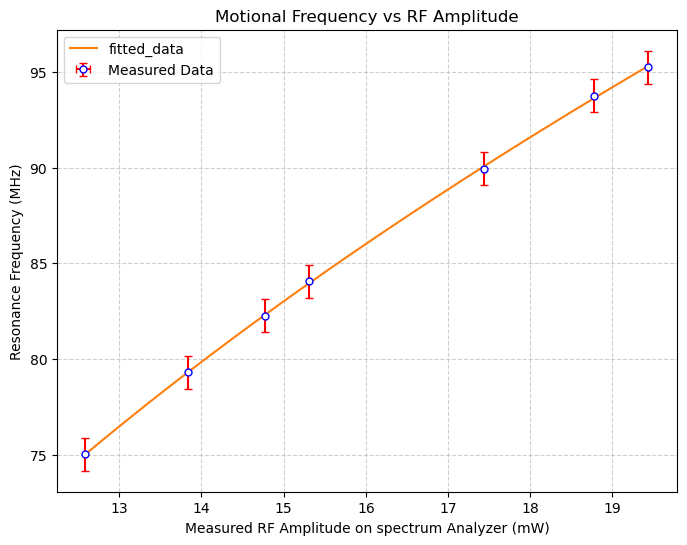

array([18.55169585,  5.91351988, 27.09328415])

In [155]:
data_branch2 = {
    #"20251209_172238": 2,  # RF_amplitude = 0.0, suspicious
    #"20251210_135743": 2,  # RF_amplitude = 0.5
    "20251210_184343": 1,  # RF_amplitude = 1.0
    "20251212_132653": 1,  # RF_amplitude = 2.0
    "20251212_185420": 2,  # RF_amplitude = 2.6
    "20251215_123555": 1,  # RF_amplitude = 3.3
    "20251215_160259": 1,  # RF_amplitude = 5.0
    "20251215_175327": 1,  # RF_amplitude = 6.0
    "20251216_142522": 1,  # RF_amplitude = 8.0
}

x_branch2, y_branch2, xerr_branch2, yerr_branch2, df_branch2 = identify_and_plot(df_lost, data_branch2, mute_plot=True, average_yerr=average_yerr)
p0_branch2 = guess_square_root4_params(x_branch2, y_branch2)
bounds_branch2 = ((0.0, -np.inf, -np.inf), (np.inf, 11.0, np.inf))
popt_branch2, pcov_branch2 = fit_and_plot(
    x_branch2, y_branch2, xerr_branch2, yerr_branch2,
    square_root4, p0=p0_branch2, bounds=bounds_branch2
)
popt_branch2

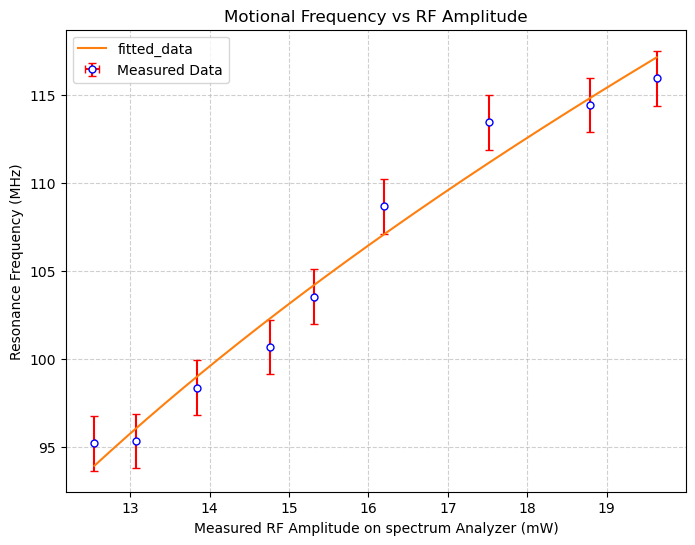

array([19.02290061,  7.29567395, 50.31435226])

In [156]:
data_branch3 = {
    #"20251210_141831": 1,  # RF_amplitude = 0.5
    "20251210_185032": 2,  # RF_amplitude = 1.0
    "20251212_133223": 2,  # RF_amplitude = 2.0
    "20251212_173612": 2,  # RF_amplitude = 1.5
    "20251212_191239": 1,  # RF_amplitude = 2.6
    "20251215_124102": 1,  # RF_amplitude = 3.3
    "20251215_143015": 2,  # RF_amplitude = 4.0
    "20251215_160758": 2,  # RF_amplitude = 5.0
    "20251215_175907": 2,  # RF_amplitude = 6.0
    "20251216_143214": 1,  # RF_amplitude = 8.0
}

x_branch3, y_branch3, xerr_branch3, yerr_branch3, df_branch3 = identify_and_plot(df_lost, data_branch3, mute_plot=True, average_yerr=average_yerr)
p0_branch3 = guess_square_root4_params(x_branch3, y_branch3)
bounds_branch3 = ((0, -np.inf, -np.inf), (np.inf, 11.0, np.inf))
popt_branch3, pcov_branch3 = fit_and_plot(
    x_branch3, y_branch3, xerr_branch3, yerr_branch3,
    square_root4, p0=p0_branch3, bounds=bounds_branch3
)
popt_branch3

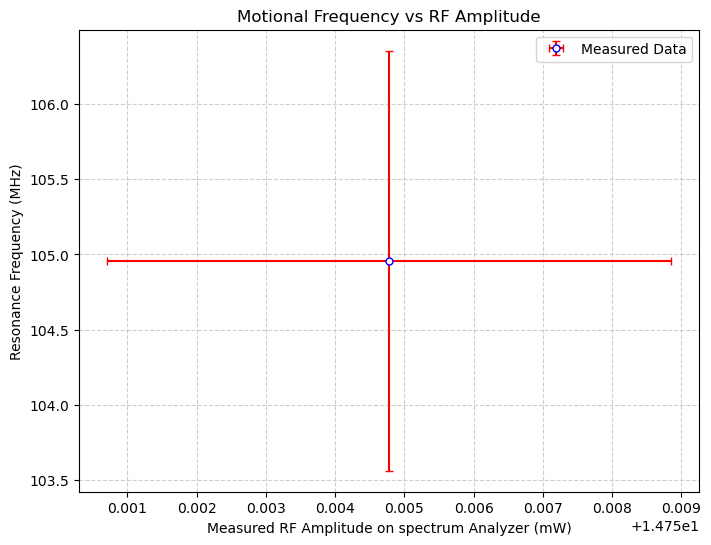

In [158]:
data_axial3 = {
    "20251212_191239": 2,  # RF_amplitude = 2.6
}

x_axial3, y_axial3, xerr_axial3, yerr_axial3, df_axial3 = identify_and_plot(df_lost, data_axial3)

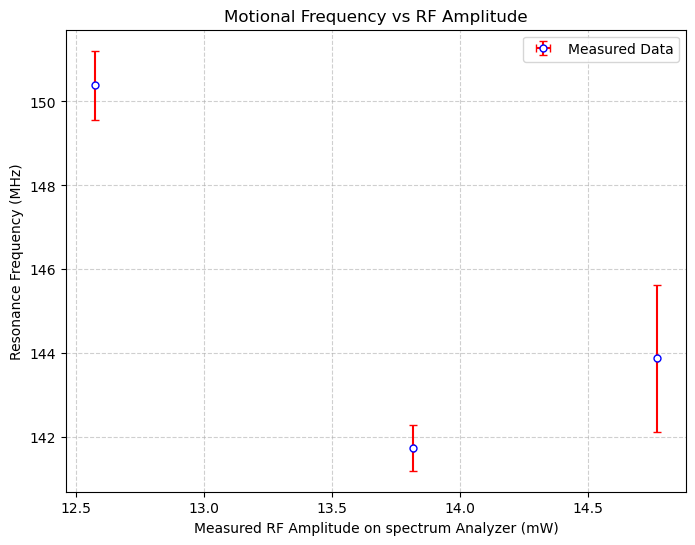

In [159]:
data_remaining = {
    "20251209_180316": 2,  # RF_amplitude = 0.0
    "20251210_185733": 1,  # RF_amplitude = 1.0
    "20251212_134210": 2,  # RF_amplitude = 2.0
    "20251212_192357": 1,  # RF_amplitude = 2.6
}

x_remaining, y_remaining, xerr_remaining, yerr_remaining, df_remaining = identify_and_plot(df_lost, data_remaining)

# The Grand Final Plot

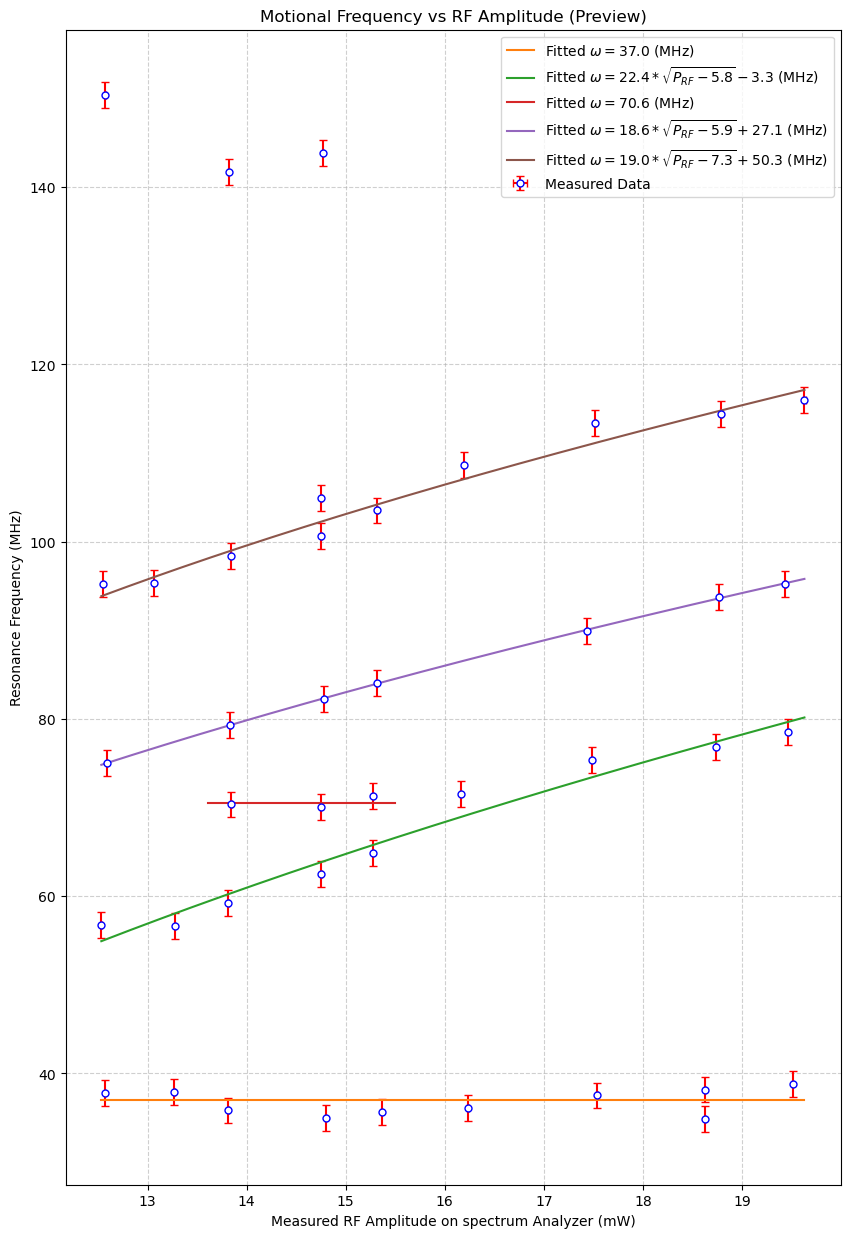

In [163]:
# Measured Data
xs = df_lost["RF_meas_linear"]
ys = df_lost["center_value"]
xerr = df_lost["RF_meas_uncertainty_linear"]
yerr = [np.mean(df_lost["sigma_value"])] * len(df_lost["sigma_value"])

# Fitted Lines
xfit = np.linspace(np.min(xs), np.max(xs), 1000)
yfit_axial = constant(xfit, *popt_axial)
yfit_branch1 = square_root4(xfit, *popt_branch1)
mask = (xfit > 13.6) * (xfit < 15.5)
xfit_axial2 = xfit[mask]
yfit_axial2 = constant(xfit_axial2, *popt_axial2)
yfit_branch2 = square_root4(xfit, *popt_branch2)
yfit_branch3 = square_root4(xfit, *popt_branch3)

plt.figure(figsize=(10, 15))
plt.errorbar(xs, ys, xerr=xerr, yerr=yerr, 
             fmt='o', markersize=5, capsize=3, 
             ecolor='red', mfc='white', mec='blue',
             label='Measured Data')
plt.plot(xfit, yfit_axial, label=rf"Fitted $\omega = {popt_axial[0]:.1f}$ (MHz)")
plt.plot(xfit, yfit_branch1, label=rf"Fitted $\omega = {popt_branch1[0]:.1f} * \sqrt{{P_{{RF}}{-popt_branch1[1]:+.1f}}}{popt_branch1[2]:+.1f}$ (MHz)")
plt.plot(xfit_axial2, yfit_axial2, label=rf"Fitted $\omega = {popt_axial2[0]:.1f}$ (MHz)")
plt.plot(xfit, yfit_branch2, label=rf"Fitted $\omega = {popt_branch2[0]:.1f} * \sqrt{{P_{{RF}}{-popt_branch2[1]:+.1f}}}{popt_branch2[2]:+.1f}$ (MHz)")
plt.plot(xfit, yfit_branch3, label=rf"Fitted $\omega = {popt_branch3[0]:.1f} * \sqrt{{P_{{RF}}{-popt_branch3[1]:+.1f}}}{popt_branch3[2]:+.1f}$ (MHz)")
plt.xlabel("Measured RF Amplitude on spectrum Analyzer (mW)")
plt.ylabel("Resonance Frequency (MHz)")
plt.title("Motional Frequency vs RF Amplitude (Preview)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

# Experimental Trial: Fitting with Joint a, b

In [166]:
# Model: shared a,b; group-specific c
def square_root4_shared_ab(xdata, a, b, c0, c1, c2):
    """
    xdata = (x_all, g_all)
      x_all: shape (N,)
      g_all: shape (N,), values in {0,1,2}
    """
    x_all, g_all = xdata
    x_all = np.asarray(x_all, dtype=float)
    g_all = np.asarray(g_all, dtype=int)

    c = np.array([c0, c1, c2], dtype=float)
    return a * np.sqrt(x_all - b) + c[g_all]


# -------------------------
# Initial guess for shared a,b with per-group c
def guess_p0_square_root4_shared_ab(xs_list, ys_list, deltas=(0.5, 0.3, 1.0, 1.5, 2.0), b_upper=None):
    """
    xs_list, ys_list: list of 3 arrays/Series: [x0,x1,x2], [y0,y1,y2]
    Return p0 = [a0, b0, c0, c1, c2]
    """
    if len(xs_list) != 3 or len(ys_list) != 3:
        raise ValueError("This helper expects exactly 3 groups.")

    xs = [np.asarray(x, dtype=float) for x in xs_list]
    ys = [np.asarray(y, dtype=float) for y in ys_list]

    for i in range(3):
        if xs[i].shape != ys[i].shape:
            raise ValueError(f"group {i}: x and y shape mismatch: {xs[i].shape} vs {ys[i].shape}")
        if xs[i].size < 2:
            raise ValueError(f"group {i}: need at least 2 points")

    xmin_global = min(float(np.min(x)) for x in xs)

    best = None  # (rss, a0, b0, c0, c1, c2, delta)

    for delta in deltas:
        delta = float(delta)
        b0 = xmin_global - delta

        if (b_upper is not None) and (b0 > float(b_upper)):
            continue

        # Build stacked data
        x_all = np.concatenate(xs)
        y_all = np.concatenate(ys)
        g_all = np.concatenate([np.full(xs[i].shape, i, dtype=int) for i in range(3)])

        dx = x_all - b0
        if np.any(dx <= 0):
            continue

        u = np.sqrt(dx)

        # Linear system: y = a*u + c0*I(g=0) + c1*I(g=1) + c2*I(g=2)
        A = np.column_stack([
            u,
            (g_all == 0).astype(float),
            (g_all == 1).astype(float),
            (g_all == 2).astype(float),
        ])

        coef, *_ = np.linalg.lstsq(A, y_all, rcond=None)
        a0, c0, c1, c2 = map(float, coef)

        yhat = A @ coef
        rss = float(np.sum((y_all - yhat) ** 2))

        cand = (rss, a0, float(b0), c0, c1, c2, delta)
        if (best is None) or (cand[0] < best[0]):
            best = cand

    if best is None:
        raise RuntimeError("No valid initial guess found. Try different deltas or relax b_upper.")

    _, a0, b0, c0, c1, c2, _ = best
    return [a0, b0, c0, c1, c2]


# -------------------------
# Fit function
def fit_square_root4_shared_ab(xs_list, ys_list, yerrs_list=None, bounds=None, p0=None,
                               deltas=(0.5, 0.3, 1.0, 1.5, 2.0), b_upper=None):
    """
    Fit 3 groups with shared (a,b) and separate (c0,c1,c2).

    bounds:
      - If None: defaults to no bounds
      - Else: bounds like curve_fit expects:
            (lower_bounds, upper_bounds)
        with 5 parameters: (a,b,c0,c1,c2)
    """
    if len(xs_list) != 3 or len(ys_list) != 3:
        raise ValueError("This fitter expects exactly 3 groups.")

    xs = [np.asarray(x, dtype=float) for x in xs_list]
    ys = [np.asarray(y, dtype=float) for y in ys_list]

    x_all = np.concatenate(xs)
    y_all = np.concatenate(ys)
    g_all = np.concatenate([np.full(xs[i].shape, i, dtype=int) for i in range(3)])

    if yerrs_list is None:
        sigma = None
    else:
        if len(yerrs_list) != 3:
            raise ValueError("yerrs_list must be None or a list of 3 arrays/Series.")
        yerrs = [np.asarray(e, dtype=float) for e in yerrs_list]
        sigma = np.concatenate(yerrs)

    if p0 is None:
        p0 = guess_p0_square_root4_shared_ab(xs, ys, deltas=deltas, b_upper=b_upper)

    if bounds is None:
        bounds = (-np.inf, np.inf)

    popt, pcov = curve_fit(
        square_root4_shared_ab,
        (x_all, g_all),
        y_all,
        p0=p0,
        bounds=bounds,
        sigma=sigma,
        absolute_sigma=(sigma is not None),
    )

    # Convenience unpack
    a, b, c0, c1, c2 = popt
    return {
        "popt": popt,
        "pcov": pcov,
        "a": float(a),
        "b": float(b),
        "cs": np.array([c0, c1, c2], dtype=float),
    }

In [167]:
res = fit_square_root4_shared_ab(
    [x_branch1, x_branch2, x_branch3],
    [y_branch1, y_branch2, y_branch3],
    yerrs_list=[yerr_branch1, yerr_branch2, yerr_branch3],  # 有就传，没有就不传
    bounds=(
        (0.0, -np.inf, -np.inf, -np.inf, -np.inf),  # a>0 只是例子
        (np.inf, 11.0,  np.inf,  np.inf,  np.inf),  # b<=10 只是例子
    ),
    b_upper=11.0,  # 让初值 b0 也自动满足 b<=10
)

res["a"], res["b"], res["cs"]

(18.46961217876868,
 6.80701786355949,
 array([12.22901674, 30.07182415, 50.33196895]))

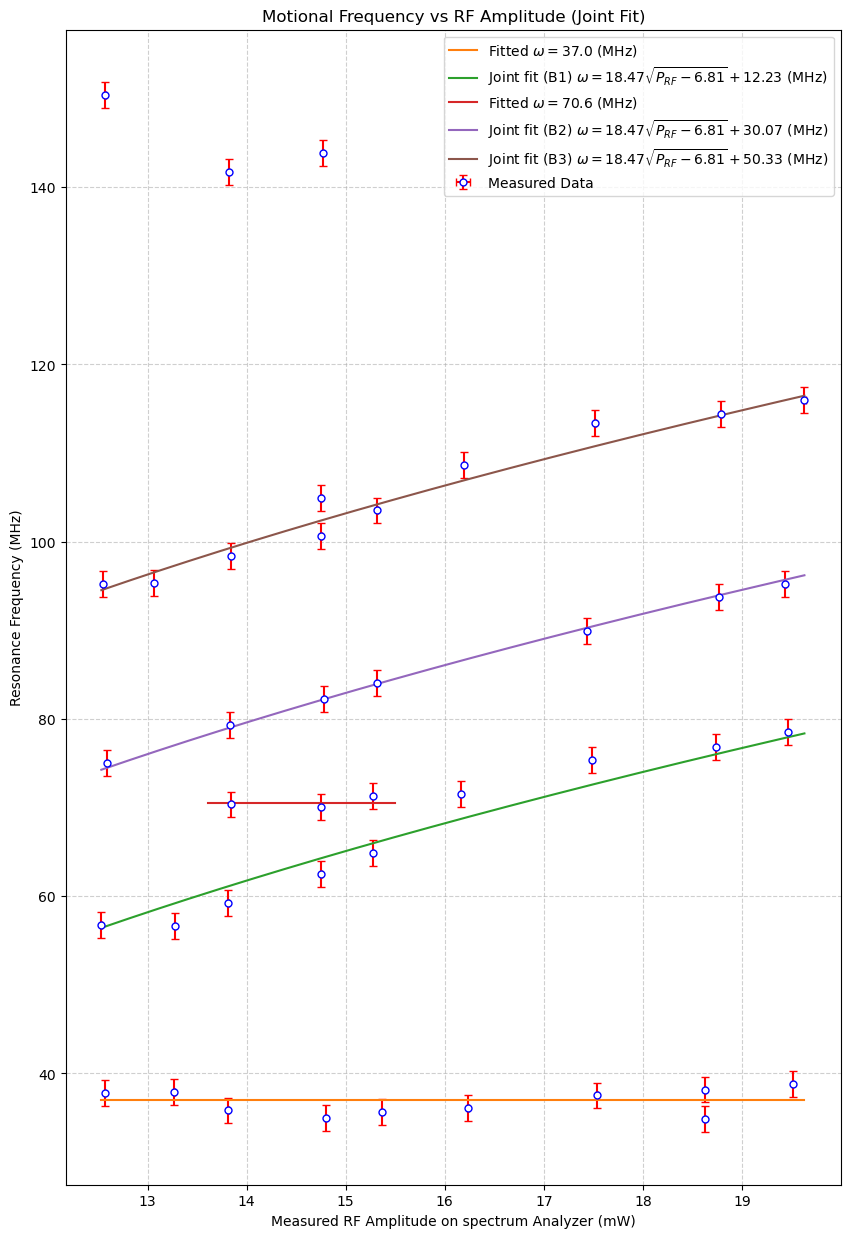

In [168]:
popt_shared = res["popt"]
a_sh, b_sh, c1, c2, c3 = popt_shared

# Measured Data (same as your example)
xs = df_lost["RF_meas_linear"]
ys = df_lost["center_value"]
xerr = df_lost["RF_meas_uncertainty_linear"]
yerr = [np.mean(df_lost["sigma_value"])] * len(df_lost["sigma_value"])

# -------------------------
# Joint-fit parameters (YOU already have these from the shared fit)
# popt_shared = [a_shared, b_shared, c_branch1, c_branch2, c_branch3]
a_sh, b_sh, c1, c2, c3 = popt_shared

# (Optional) if you also have axial fits
# popt_axial  = [w0]
# popt_axial2 = [w0_2]

# -------------------------
# Fitted lines
xfit = np.linspace(np.min(xs), np.max(xs), 1000)

# domain mask (avoid sqrt of negative)
mask_dom = xfit > b_sh

# Shared-shape branches (option A: draw across full x-range but only where domain valid)
yfit_branch1 = np.full_like(xfit, np.nan, dtype=float)
yfit_branch2 = np.full_like(xfit, np.nan, dtype=float)
yfit_branch3 = np.full_like(xfit, np.nan, dtype=float)

yfit_branch1[mask_dom] = square_root4(xfit[mask_dom], a_sh, b_sh, c1)
yfit_branch2[mask_dom] = square_root4(xfit[mask_dom], a_sh, b_sh, c2)
yfit_branch3[mask_dom] = square_root4(xfit[mask_dom], a_sh, b_sh, c3)

# Optional: axial constant lines (if you have them)
# yfit_axial = constant(xfit, *popt_axial)
# mask2 = (xfit > 13.6) & (xfit < 15.5)
# xfit_axial2 = xfit[mask2]
# yfit_axial2 = constant(xfit_axial2, *popt_axial2)

# -------------------------
# Plot
plt.figure(figsize=(10, 15))

plt.errorbar(xs, ys, xerr=xerr, yerr=yerr,
             fmt='o', markersize=5, capsize=3,
             ecolor='red', mfc='white', mec='blue',
             label='Measured Data')

# Optional: plot axial lines if you have them
# plt.plot(xfit, yfit_axial, label=rf"Fitted $\omega = {popt_axial[0]:.1f}$ (MHz)")
# plt.plot(xfit_axial2, yfit_axial2, label=rf"Fitted $\omega = {popt_axial2[0]:.1f}$ (MHz)")

# Joint branches
plt.plot(xfit, yfit_axial, label=rf"Fitted $\omega = {popt_axial[0]:.1f}$ (MHz)")
plt.plot(xfit, yfit_branch1,
         label=rf"Joint fit (B1) $\omega = {a_sh:.2f}\sqrt{{P_{{RF}} - {b_sh:.2f}}} {c1:+.2f}$ (MHz)")
plt.plot(xfit_axial2, yfit_axial2, label=rf"Fitted $\omega = {popt_axial2[0]:.1f}$ (MHz)")
plt.plot(xfit, yfit_branch2,
         label=rf"Joint fit (B2) $\omega = {a_sh:.2f}\sqrt{{P_{{RF}} - {b_sh:.2f}}} {c2:+.2f}$ (MHz)")
plt.plot(xfit, yfit_branch3,
         label=rf"Joint fit (B3) $\omega = {a_sh:.2f}\sqrt{{P_{{RF}} - {b_sh:.2f}}} {c3:+.2f}$ (MHz)")

plt.xlabel("Measured RF Amplitude on spectrum Analyzer (mW)")
plt.ylabel("Resonance Frequency (MHz)")
plt.title("Motional Frequency vs RF Amplitude (Joint Fit)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()